In [7]:
#%matplotlib inline

In [1]:
import os, glob
import pandas as pd
import numpy as np

import cv2
from moviepy import VideoFileClip

import ipywidgets as widgets
from ipywidgets import VBox, Dropdown, Button

from IPython.display import Video, display, clear_output


In [2]:
#!uv pip install ipywidgets

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
tag_path = "/home/mstlaure/Documents/Marie/neuromod/friends_annotations/data/audio_tags/indices_FriendsAudioAnnot.csv"
#tag_path = "/home/mstlaure/Documents/Marie/neuromod/friends_annotations/data/audio_tags/indices_FriendsAudioAnnot_orig.csv"

fig_save_path = "/home/mstlaure/Documents/Marie/neuromod/friends_annotations/data/audio_tags"
save_fig = True

movie_path = "/home/mstlaure/Documents/Marie/neuromod/tests/test/algonauts_2025.competitors/stimuli/movies/friends"
temp_path = "/home/mstlaure/Documents/Marie/neuromod/friends_annotations/data/audio_tags/temp.mp4"

In [28]:

SMALL_SIZE = 24
MEDIUM_SIZE = 24
BIGGER_SIZE = 24

plt.rc('font', size=SMALL_SIZE)  # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)  # fontsize of the axes title
plt.rc('axes', labelsize=BIGGER_SIZE)  # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)  # fontsize of the tick labels
plt.rc('ytick', labelsize=BIGGER_SIZE)  # fontsize of the tick labels
plt.rc('legend', fontsize=BIGGER_SIZE)  # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title    


human_tags= ['tag_Talking',
 'tag_Speech',
 'tag_Man_speaking',
 'tag_Woman_speaking',
 'tag_Conversation',
 'tag_Baby',
 'tag_Shout',
 'tag_Whispering',
 'tag_Laughter',
 'tag_Cry',
 'tag_Singing',
 'tag_Kids',
 'tag_Groan',
 'tag_Whistling',
 'tag_Breathing',
 'tag_Cough_sneeze',
 'tag_Walking',
 'tag_Mouth_sounds',
 'tag_Fart',
 'tag_Hands',
 'tag_Heartbeat',
 'tag_Cheering',
 'tag_Crowd',
]

animal_tags= [
 'tag_Mammal',
 'tag_Dog bark',
 'tag_Cat',
 'tag_Rooster',
 'tag_Duck',
 'tag_Bird',
 'tag_Amphibian',
 'tag_Reptile',
 'tag_Buzz',
 'tag_Snake_Frog',
 'tag_Insect', 
 'buzz',
 'domesticanimals',
]

music_tags= [
 'tag_Singing',
 'tag_Music',
 'tag_Musical_instrument',
 'tag_Guitar',
 'tag_Piano',
 'tag_Organ',
 'tag_Electronic_instrument',
 'tag_Percussion',
 'tag_Bell',
 'tag_Ambient_music',
 'tag_Video_game_music',
 'tag_Christmas_music',
 'tag_Wedding_music',
]

elements_tags= [
 'tag_Weather',
 'tag_Wind',
 'tag_Rain',
 'tag_River',
 'tag_Wave',
 'tag_Thunder',
 'tag_River_sea',
 'tag_Fire',
]

vehicles_tags= [
 'tag_Boat',
 'tag_Car',
 'tag_Others_motors',
 'tag_Motorbike',
 'tag_Car honk',
 'tag_Emergency_vehicle',
 'tag_Train',
 'tag_Plane',
 'tag_Helicopter',
 'tag_Cycling',
 'tag_Skateboard',
 'tag_Engine',
]

home_tags= [
 'tag_Door',
 'tag_Doorbell',
 'tag_Knock',
 'tag_Rolling shutter',
 'tag_Kitchen sounds',
 'tag_Cupboard',
 'tag_Drawer',
 'tag_Cooking',
 'tag_Hair_dryer',
 'tag_Toilet_flush',
 'tag_Toothbrush',
 'tag_Vacuum',
 'tag_Zipper',
 'tag_Keys',
 'tag_Scissors',
 'tag_Shaver',
 'tag_Shuffling_cards',
 'tag_Typing',
 'tag_Alarm',
 'tag_Telephone',
 'tag_Whistle',
 'tag_Mechanisms',
 'tag_Camera',
 'tag_Air_conditioning',
 'tag_Radio_TV',    
]

noises_tags= [
 'tag_Cash_register',
 'tag_Tools',
 'tag_Shoot',
 'tag_Boom',
 'tag_Wood',
 'tag_Crack',
 'tag_Glass',
 'tag_Water',
 'tag_Arrow',
 'tag_Bang',
 'tag_Bouncing',
 'tag_Whip',
 'tag_Flap',
 'tag_Scratch',
 'tag_Roll',
 'tag_Crushing',
 'tag_Tearing',
 'tag_Beep',
 'tag_Clang',
 'tag_Squeal',
 'tag_Creak',
 'tag_Whir',
 'tag_Sizzle',
 'tag_Rumble',
 'tag_Plop',
 'tag_Silence',
 'tag_Noise',    
]

environ_tags= [
 'tag_Inside',
 'tag_Outside',
 'tag_Outside_urban',
 'tag_Outside_natural',
 'tag_Noise',
 'geophony',
 'biophony',
 'anthropophony',
]

tags = {
    0: environ_tags,
    1: noises_tags,
    2: home_tags,
    3: vehicles_tags,
    4: elements_tags,
    5: music_tags,
    6: animal_tags,
    7: human_tags,
}


def make_df(df, t):
    df_t = df[[t]].copy()
    df_t = df_t.rename(columns={t: 'score'})
    df_t["tag"] = pd.Series(np.repeat(t, df.shape[0]))
    
    return df_t


def plot_audiotags(epi_df, chunk_df, tag_list):
    """."""
    fig, ax = plt.subplots(figsize=(22, 6))
    
    for i, t in enumerate(tag_list):
        ax.scatter(
            np.repeat(i, epi_df.shape[0]),
            epi_df[t],
            alpha=0.3,
            s=100,
            c='gray',
            #label=t.replace("tag_", ""),
        )
        ax.scatter(
            np.repeat(i, chunk_df.shape[0]),
            chunk_df[t],
            alpha=1.00,
            s=200,
            c='red',
            #label=t.replace("tag_", ""),
        )
    
    ax.set_ylim(-0.05, 1.01)
    ax.set_xticks(range(len(tag_list)))
    ax.set_xticklabels([t.replace("tag_", "") for t in tag_list], rotation=90)
    
    plt.show()


def fix_name(row):
    '''
    Remove placeholder date & time info from episode name
    '''
    return row['name'].split('_')[1]


def load_tagdf(tag_path, epi, tag_num):
    """
    Loads an audio tag file and returns episode's audio tags as a DataFrame.

    Parameters
    ----------
    tag_path : str
        Path to the .csv file with audio tags.
    epi : str
        Episode number, e.g., s01e02b
    tag_num : int
        Number corresponding to set of annotations to plot
            0: environ_tags,
            1: noises_tags,
            2: home_tags,
            3: vehicles_tags,
            4: elements_tags,
            5: music_tags,
            6: animal_tags,
            7: human_tags,
    """
    df = pd.read_csv(tag_path, sep= ",")
    sort_df = df.sort_values(by=['name', 'start'])
    sort_df['name'] = sort_df.apply(lambda row: fix_name(row), axis=1)
    
    sort_df = sort_df.rename(
        columns={
            'name': 'episode_id', 
            'start': 'onset',
        }
    )
    sort_df.insert(loc=2, column='duration', value=5.0)
    final_cols = ['episode_id', 'onset', 'duration'] + sort_df.columns.tolist()[5:]
    sort_df = sort_df[final_cols]

    return sort_df[sort_df['episode_id']==epi][['episode_id', 'onset', 'duration']+tags[tag_num]], tags[tag_num]
    

def get_movie_info(movie_path):
    """
    Extracts the frame rate (FPS) and total duration of a movie.

    Parameters
    ----------
    movie_path : str
        Path to the .mkv movie file.

    """

    cap = cv2.VideoCapture(movie_path)
    fps, frame_count = cap.get(cv2.CAP_PROP_FPS), cap.get(cv2.CAP_PROP_FRAME_COUNT)
    cap.release()

    return fps, frame_count / fps


def split_movie_into_chunks(movie_path, chunk_duration=1.49):
    """
    Divides a video into fixed-duration chunks.

    Parameters
    ----------
    movie_path : str
        Path to the .mkv movie file.
    chunk_duration : float, optional
        Duration of each chunk in seconds (default is 1.49).

    """

    _, video_duration = get_movie_info(movie_path)
    chunks = []
    start_time = 0.0

    # Create chunks for the specified time
    while start_time < video_duration:
        end_time = min(start_time + chunk_duration, video_duration)
        chunks.append((start_time, end_time))
        start_time += chunk_duration
    return chunks


def create_dropdown_by_onset(tag_df):
    """
    Creates a dropdown widget for selecting chunks by their onset time (in seconds).

    Parameters
    ----------
    tag_df : DataFrame
        DataFrame containing tag data.

    """

    options = []

    # Iterate over each row in the tag DataFrame (each an annotated 5s window)
    for i, row in tag_df.iterrows():
        options.append((row['onset'], i))

    return widgets.Dropdown(options=options, description='Select segment:')
    

def extract_movie_segment_with_sound(movie_path, start_time, end_time,
    output_path='output_segment.mp4'):
    """
    Extracts a specific segment of a video with sound and saves it.

    Parameters
    ----------
    movie_path : str
        Path to the .mkv movie file.
    start_time : float
        Start time of the segment in seconds.
    end_time : float
        End time of the segment in seconds.
    output_path : str, optional
        Path to save the output segment (default is 'output_segment.mp4').

    """

    # Create movie segment
    movie_segment = VideoFileClip(movie_path).subclipped(start_time, end_time)
    print(f"\nWriting movie file from {start_time}s until {end_time}s")

    # Write video file
    movie_segment.write_videofile(output_path, codec="libx264",
        audio_codec="aac", logger=None)
    return output_path


def display_transcript_and_movie(chunk_index, tag_df, tag_list, chunks,
    movie_path, temp_mvpath):
    """
    Displays transcript, movie, onset, and duration for a selected chunk.

    Parameters
    ----------
    chunk_index : int
        Index of the selected chunk.
    tag_df : DataFrame
        DataFrame containing audiotag data.
    chunks : list
        List of (start_time, end_time) tuples for video chunks.
    movie_path : str
        Path to the .mkv movie file.

    """
    # Retrieve the start and end times for the selected chunk
    start_time, end_time = chunks[chunk_index]

    # Get the corresponding transcript row if it exists in the DataFrame
    tag_chunk = tag_df.iloc[chunk_index:chunk_index+1] if chunk_index < len(tag_df) else None

    # Display the stimulus chunk number
    print(f"\nChunk number: {chunk_index + 1}")

    # Display audiotag details 
    if tag_chunk is not None:
        plot_audiotags(tag_df, tag_chunk, tag_list)
    else:
        print("<No annotations for this scene>")

    # Extract and display the video segment
    output_movie_path = extract_movie_segment_with_sound(movie_path, start_time,
        end_time, output_path=temp_mvpath)
    display(Video(output_movie_path, embed=True, width=640, height=480))
    

def interface_display_tags_and_movie(movie_path, tag_path, temp_mvpath, epi, tag_num):
    """
    Interactive interface to align movie and audio annotations.

    Parameters
    ----------
    movie_path : str
        Path to the .mkv movie file.
    tag_path : str
        Path to the .csv file with audio tags.
    epi : str
        Episode number, e.g., s01e02b
    tag_num : int
        Number corresponding to set of annotations to plot
            0: environ_tags,
            1: noises_tags,
            2: home_tags,
            3: vehicles_tags,
            4: elements_tags,
            5: music_tags,
            6: animal_tags,
            7: human_tags,
    """

    # Load the audio tag data from the provided path
    tag_df, tag_list = load_tagdf(tag_path, epi, tag_num)
    
    # Split the video file into chunks of 5 seconds (audio tag window)
    s = epi[2]
    chunks = split_movie_into_chunks(
        f"{movie_path}/s{s}/friends_{epi}.mkv",
        chunk_duration=5.0,
    )

    # Create a dropdown widget with transcript text as options
    dropdown = create_dropdown_by_onset(tag_df)

    # Create an output widget to display video and transcript details
    output = widgets.Output()

    # Display the dropdown and output widgets
    display(dropdown, output)

    # Define the function to handle dropdown value changes
    def on_chunk_select(change):
        output.clear_output()  # Clears previous content
        with output:
            #output.clear_output()  # Clears previous content
            chunk_index = dropdown.value
            display_transcript_and_movie(
                chunk_index, 
                tag_df, 
                tag_list,
                chunks,
                f"{movie_path}/s{s}/friends_{epi}.mkv", 
                temp_mvpath,
            )

    dropdown.observe(on_chunk_select, names='value')
        

In [37]:
"""
tags = {
    0: environ_tags,
    1: noises_tags,
    2: home_tags,
    3: vehicles_tags,
    4: elements_tags,
    5: music_tags,
    6: animal_tags,
    7: human_tags,
}
"""
epi = 's01e01a'
tag_num = 5

interface_display_tags_and_movie(
    movie_path, 
    tag_path, 
    temp_path, 
    epi, 
    tag_num,
)

Dropdown(description='Select segment:', options=((0.0, 0), (5.0, 1), (10.0, 2), (15.0, 3), (20.0, 4), (25.0, 5…

Output()

In [9]:
tag_df = pd.read_csv(tag_path, sep= ",")
tag_df.head()

,name,start,datetime,flacfile,tag_Talking,tag_Speech,tag_Man_speaking,tag_Woman_speaking,tag_Conversation,tag_Baby,...,tag_Outside_urban,tag_Outside_natural,tag_Noise,tag_Radio_TV,geophony,biophony,anthropophony,buzz,domesticanimals,dB
0,friends_s01e01a_20010101_101010.wav,0.0,20010101_101010,20010101_101010.flac,0.063302,0.063302,0.001418,0.004460,0.000194,0.000844,...,0.007377,0.025633,0.007757,0.000767,0.005291,0.004923,0.171270,0.001972,0.003154,-inf
1,friends_s01e01a_20010101_101010.wav,5.0,20010101_101015,20010101_101015.flac,0.016602,0.016602,0.006227,0.001466,0.000096,0.000129,...,0.005154,0.015250,0.003435,0.002236,0.002187,0.002757,0.650377,0.000578,0.001304,-24.487238
2,friends_s01e01a_20010101_101010.wav,10.0,20010101_101020,20010101_101020.flac,0.260924,0.260924,0.008632,0.002139,0.001278,0.000124,...,0.079215,0.053726,0.010695,0.002983,0.032453,0.006645,0.260924,0.002728,0.003082,-28.259907
3,friends_s01e01a_20010101_101010.wav,15.0,20010101_101025,20010101_101025.flac,0.753515,0.753515,0.009927,0.047548,0.010457,0.000258,...,0.072313,0.035979,0.010455,0.001905,0.006284,0.016756,0.753515,0.002731,0.010976,-24.001646
4,friends_s01e01a_20010101_101010.wav,20.0,20010101_101030,20010101_101030.flac,0.828213,0.828213,0.006873,0.033001,0.011973,0.000444,...,0.013600,0.027096,0.000506,0.001349,0.006573,0.057732,0.828213,0.000447,0.057732,-22.034472


In [10]:
tag_df.columns.tolist()


['name',
 'start',
 'datetime',
 'flacfile',
 'tag_Talking',
 'tag_Speech',
 'tag_Man_speaking',
 'tag_Woman_speaking',
 'tag_Conversation',
 'tag_Baby',
 'tag_Shout',
 'tag_Whispering',
 'tag_Laughter',
 'tag_Cry',
 'tag_Singing',
 'tag_Kids',
 'tag_Groan',
 'tag_Whistling',
 'tag_Breathing',
 'tag_Cough_sneeze',
 'tag_Walking',
 'tag_Mouth_sounds',
 'tag_Fart',
 'tag_Hands',
 'tag_Heartbeat',
 'tag_Cheering',
 'tag_Crowd',
 'tag_Mammal',
 'tag_Dog bark',
 'tag_Cat',
 'tag_Rooster',
 'tag_Duck',
 'tag_Bird',
 'tag_Amphibian',
 'tag_Reptile',
 'tag_Buzz',
 'tag_Snake_Frog',
 'tag_Insect',
 'tag_Music',
 'tag_Musical_instrument',
 'tag_Guitar',
 'tag_Piano',
 'tag_Organ',
 'tag_Electronic_instrument',
 'tag_Percussion',
 'tag_Bell',
 'tag_Ambient_music',
 'tag_Video_game_music',
 'tag_Christmas_music',
 'tag_Wedding_music',
 'tag_Weather',
 'tag_Wind',
 'tag_Rain',
 'tag_River',
 'tag_Wave',
 'tag_Thunder',
 'tag_River_sea',
 'tag_Fire',
 'tag_Boat',
 'tag_Car',
 'tag_Others_motors',
 '

In [11]:
def make_df(df, t):
    df_t = df[[t]].copy()
    df_t = df_t.rename(columns={t: 'score'})
    df_t["tag"] = pd.Series(np.repeat(t, df.shape[0]))
    
    return df_t

SMALL_SIZE = 24
MEDIUM_SIZE = 24
BIGGER_SIZE = 24

plt.rc('font', size=SMALL_SIZE)  # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)  # fontsize of the axes title
plt.rc('axes', labelsize=BIGGER_SIZE)  # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)  # fontsize of the tick labels
plt.rc('ytick', labelsize=BIGGER_SIZE)  # fontsize of the tick labels
plt.rc('legend', fontsize=BIGGER_SIZE)  # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title    

[]

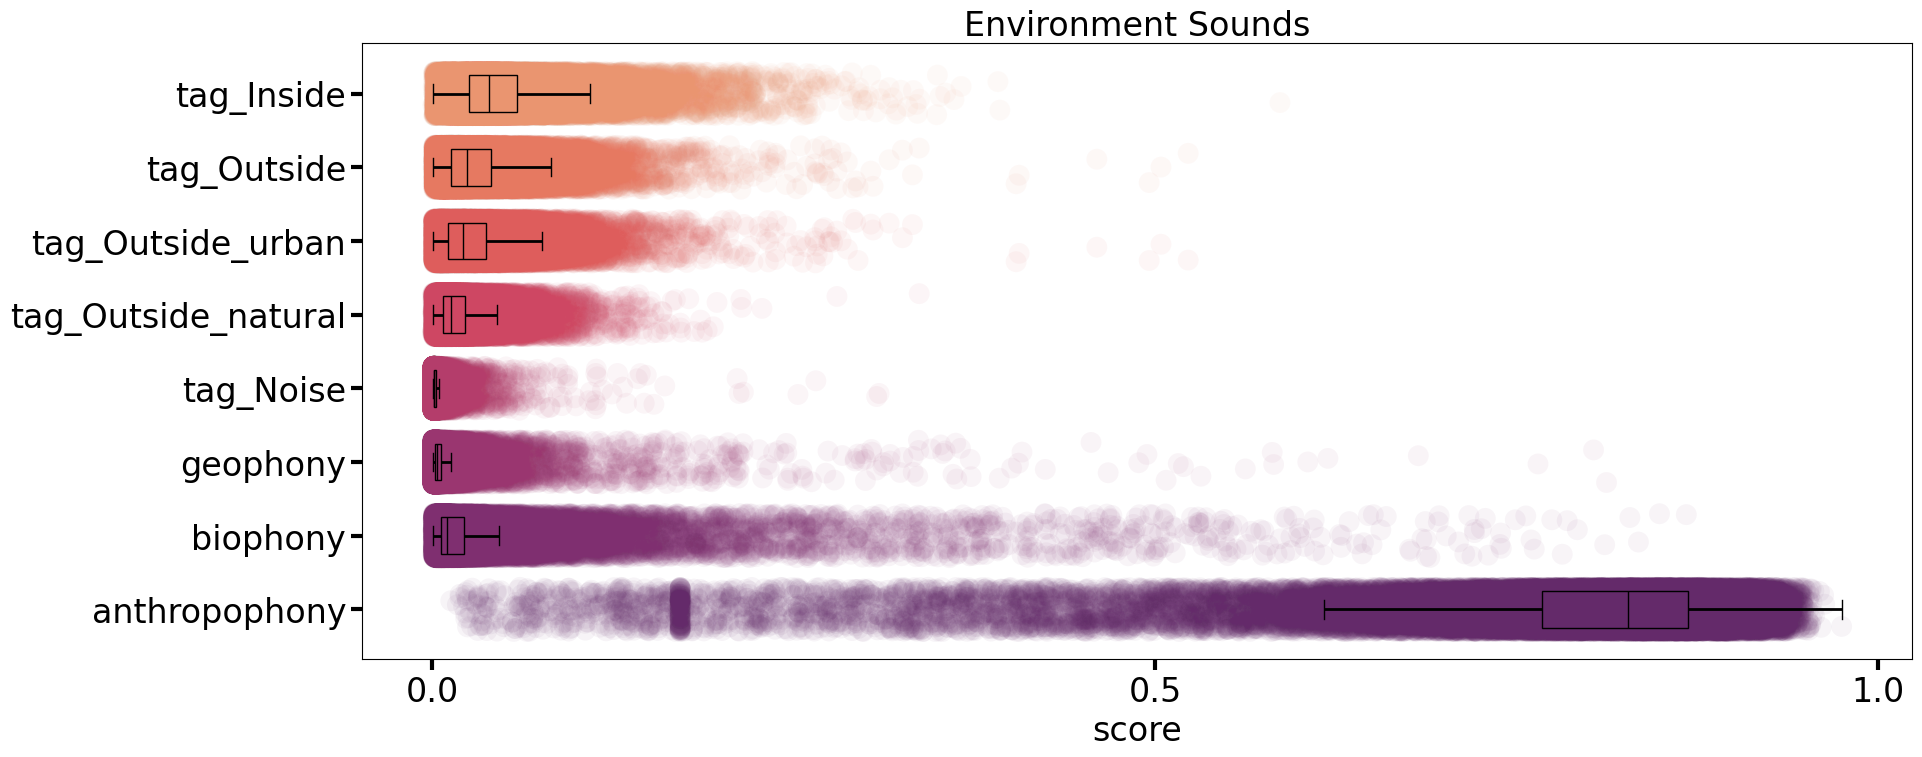

In [12]:
# Environment sounds

tags= [
 'tag_Inside',
 'tag_Outside',
 'tag_Outside_urban',
 'tag_Outside_natural',
 'tag_Noise',
 'geophony',
 'biophony',
 'anthropophony',
]

df = pd.concat([
    make_df(tag_df, t) for t in tags
])

fig, ax = plt.subplots(figsize=(20, len(tags)))
dx='score'; dy='tag'; ort="h" 
#pal = sns.color_palette("rocket")
pal = sns.color_palette("flare", len(tags))

ax=sns.stripplot(x = dx, y = dy, data = df, palette = pal, hue = dy, edgecolor = "white",
                 size = 3, alpha=0.05, s=15, jitter = 0.3, zorder = 0, orient = ort)

ax=sns.boxplot(x = dx, y = dy, data = df, color = "black", width = .50, zorder = 10, 
               showcaps = True, boxprops = {'facecolor':'none', "zorder":10},
               showfliers=False, whiskerprops = {'linewidth':2, "zorder":10},
               saturation = 1, orient = ort)

ax.tick_params(width=3, size=8)

plt.xticks([0.0, 0.5, 1.0])
#plt.xlabel('')
plt.ylabel('')

plt.title("Environment Sounds")

if save_fig:
    #plt.savefig(f"{fig_save_path}/Environment_sounds.png", dpi=600, bbox_inches='tight')
    plt.savefig(f"{fig_save_path}/Environment_sounds.png", bbox_inches='tight')
    
plt.plot()



[]

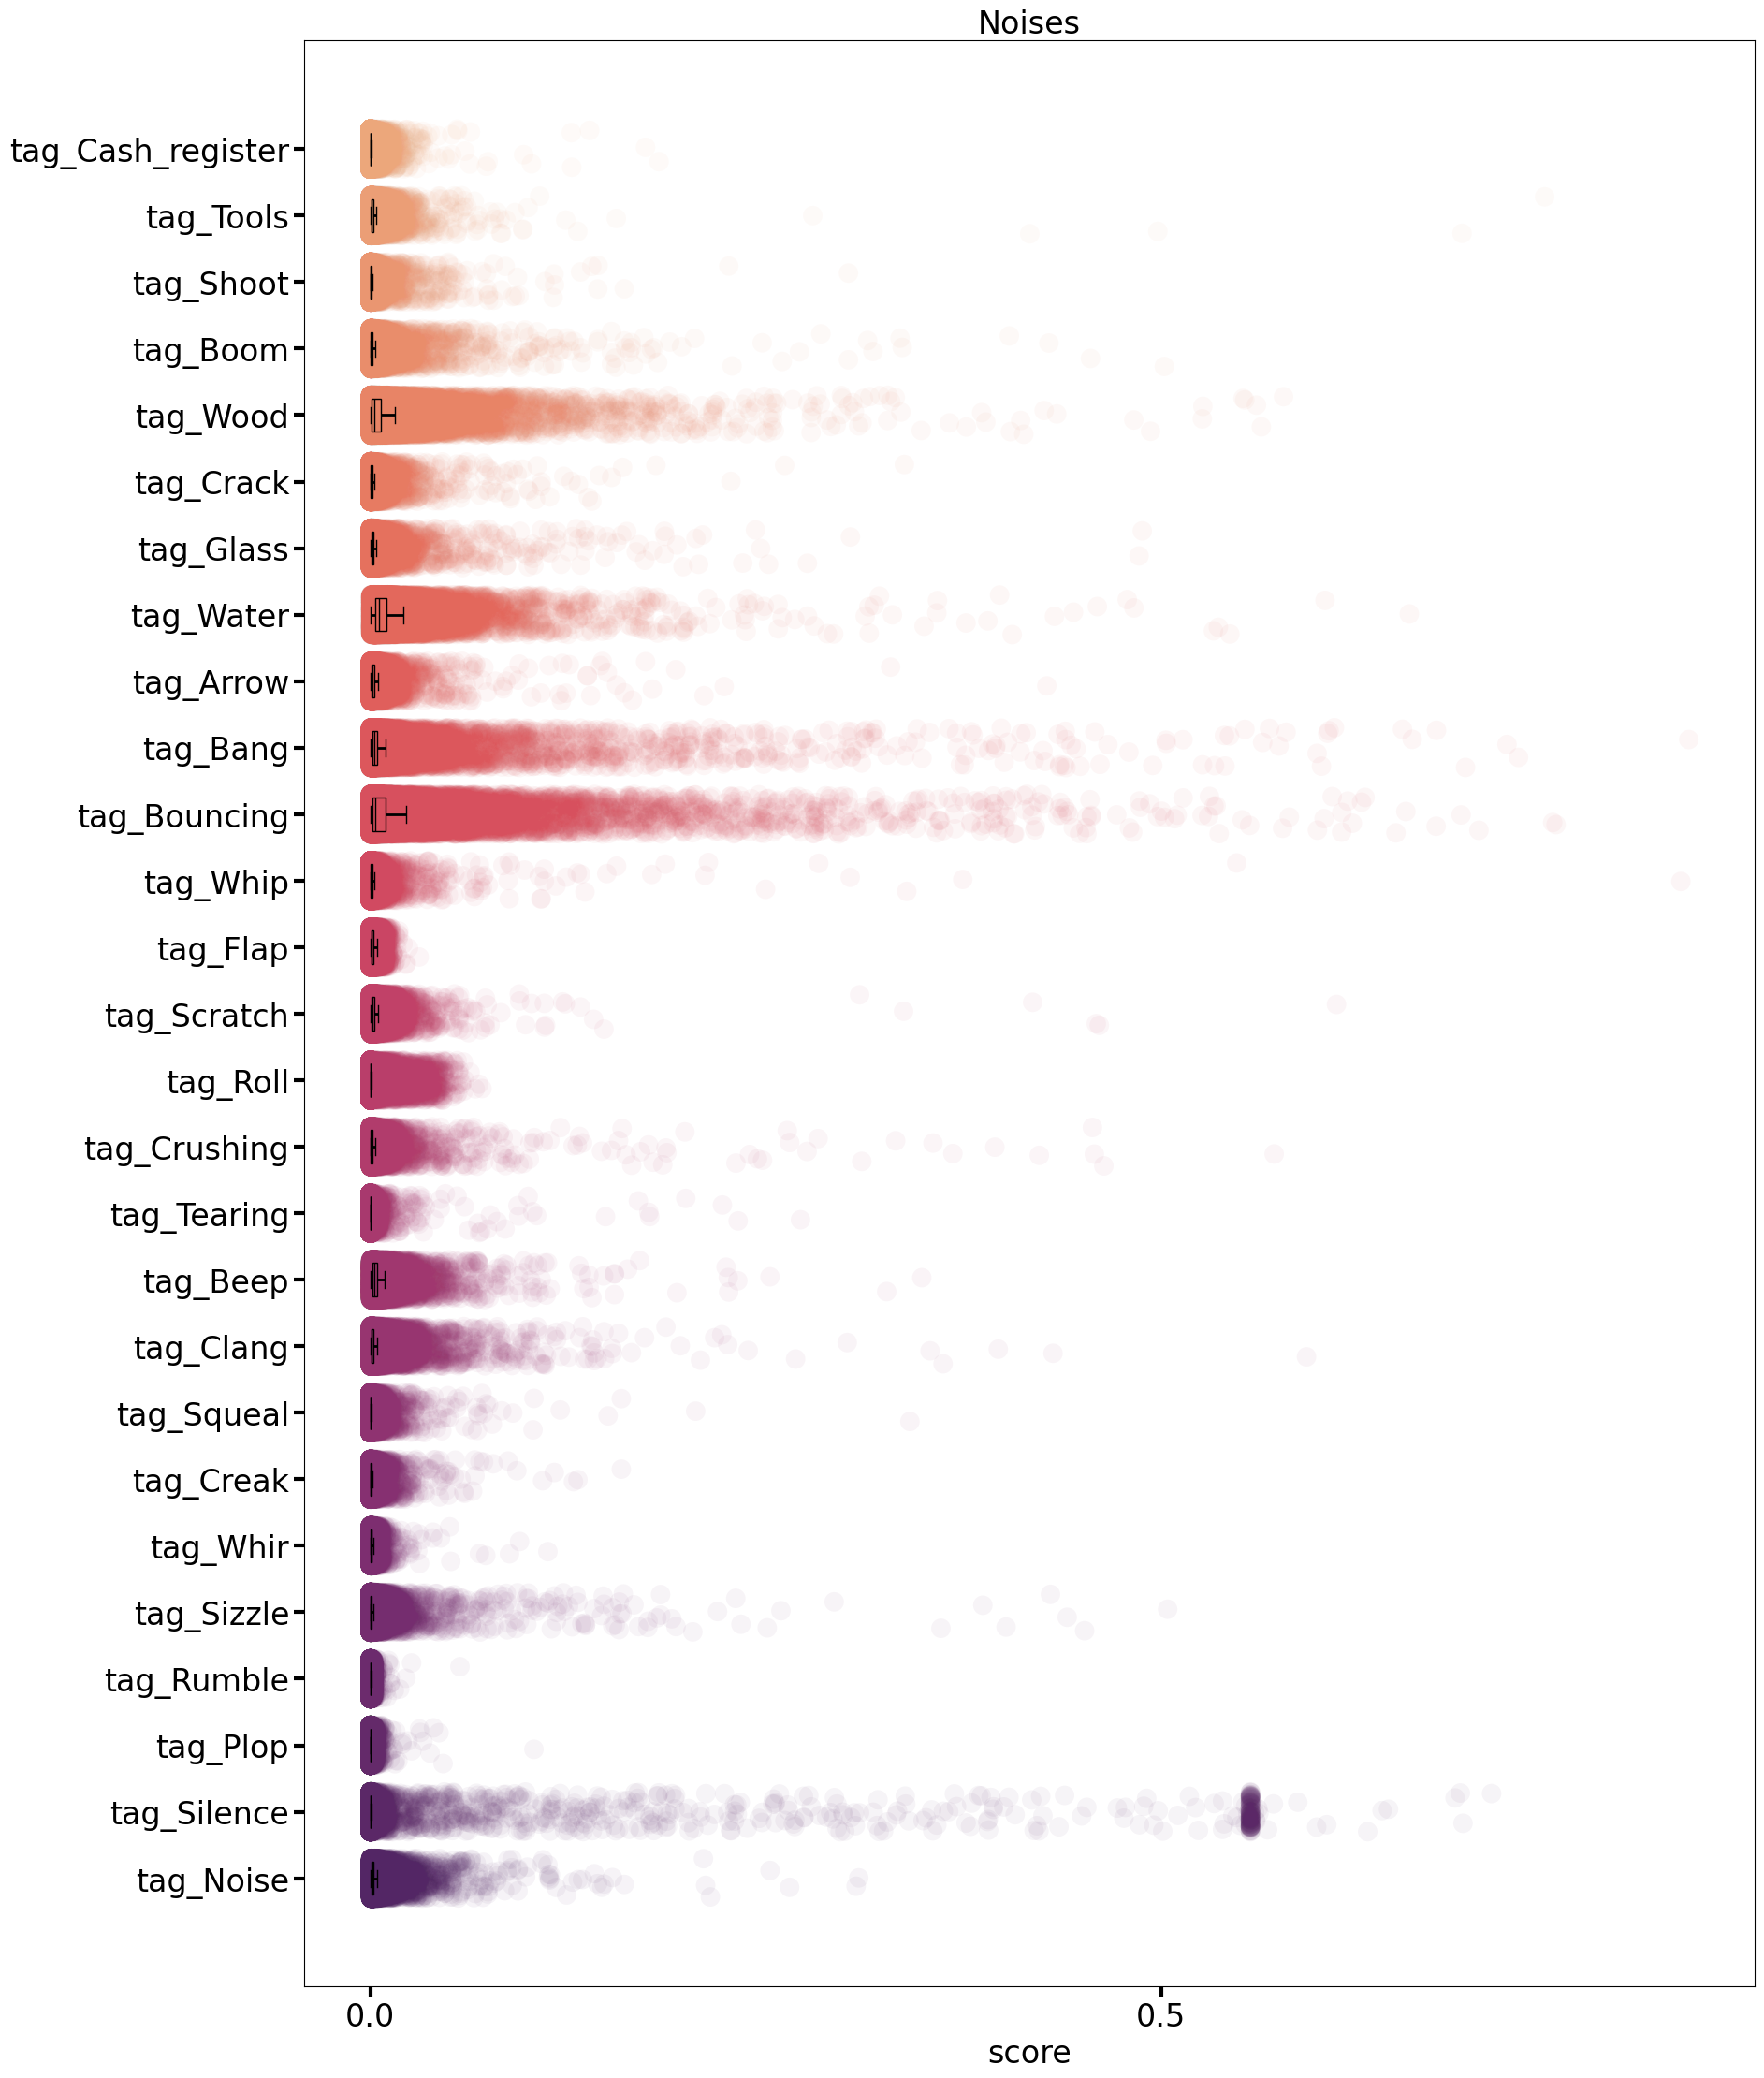

In [13]:
# Noises

tags= [
 'tag_Cash_register',
 'tag_Tools',
 'tag_Shoot',
 'tag_Boom',
 'tag_Wood',
 'tag_Crack',
 'tag_Glass',
 'tag_Water',
 'tag_Arrow',
 'tag_Bang',
 'tag_Bouncing',
 'tag_Whip',
 'tag_Flap',
 'tag_Scratch',
 'tag_Roll',
 'tag_Crushing',
 'tag_Tearing',
 'tag_Beep',
 'tag_Clang',
 'tag_Squeal',
 'tag_Creak',
 'tag_Whir',
 'tag_Sizzle',
 'tag_Rumble',
 'tag_Plop',
 'tag_Silence',
 'tag_Noise',    
]

df = pd.concat([
    make_df(tag_df, t) for t in tags
])

fig, ax = plt.subplots(figsize=(20, len(tags)))
dx='score'; dy='tag'; ort="h" 
#pal = sns.color_palette("rocket")
pal = sns.color_palette("flare", len(tags))

ax=sns.stripplot(x = dx, y = dy, data = df, palette = pal, hue = dy, edgecolor = "white",
                 size = 3, alpha=0.05, s=15, jitter = 0.3, zorder = 0, orient = ort)

ax=sns.boxplot(x = dx, y = dy, data = df, color = "black", width = .50, zorder = 10, 
               showcaps = True, boxprops = {'facecolor':'none', "zorder":10},
               showfliers=False, whiskerprops = {'linewidth':2, "zorder":10},
               saturation = 1, orient = ort)

ax.tick_params(width=3, size=8)

plt.xticks([0.0, 0.5, 1.0])
#plt.xlabel('')
plt.ylabel('')

plt.title("Noises")
if save_fig:
    #plt.savefig(f"{fig_save_path}/Environment_sounds.png", dpi=600, bbox_inches='tight')
    plt.savefig(f"{fig_save_path}/Noises.png", bbox_inches='tight')
    
plt.plot()


[]

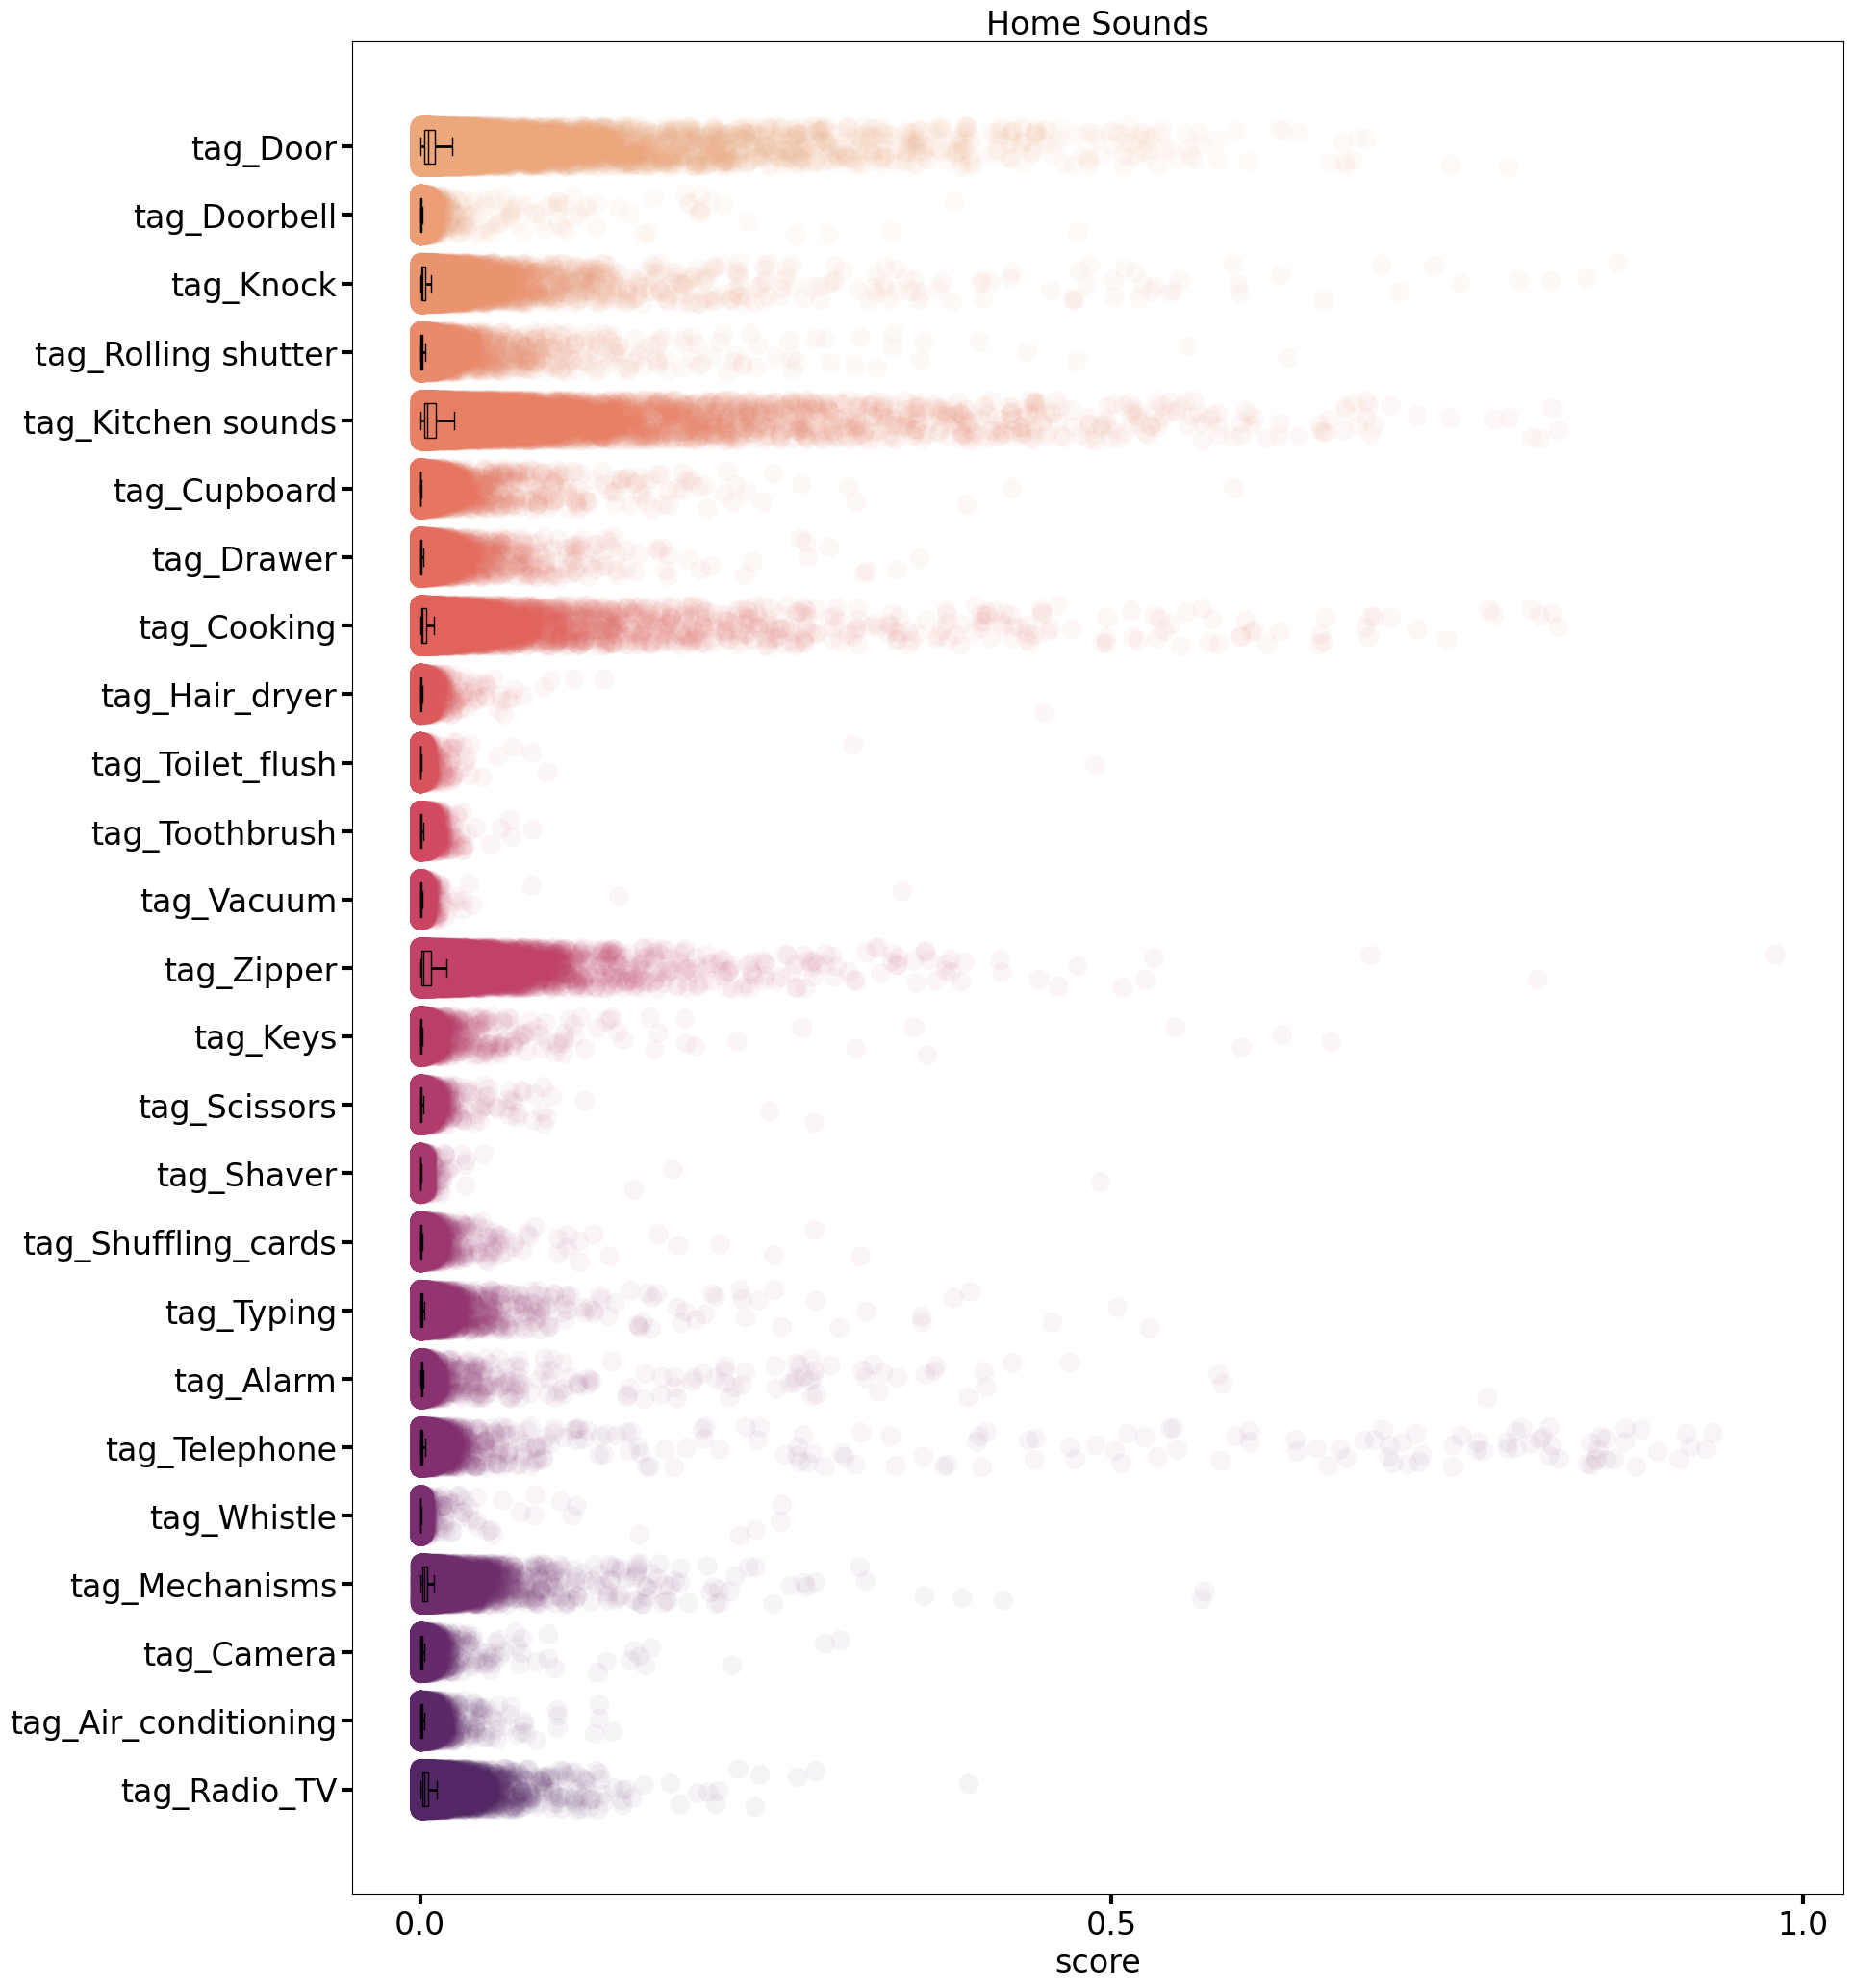

In [14]:
# Home Sounds

tags= [
 'tag_Door',
 'tag_Doorbell',
 'tag_Knock',
 'tag_Rolling shutter',
 'tag_Kitchen sounds',
 'tag_Cupboard',
 'tag_Drawer',
 'tag_Cooking',
 'tag_Hair_dryer',
 'tag_Toilet_flush',
 'tag_Toothbrush',
 'tag_Vacuum',
 'tag_Zipper',
 'tag_Keys',
 'tag_Scissors',
 'tag_Shaver',
 'tag_Shuffling_cards',
 'tag_Typing',
 'tag_Alarm',
 'tag_Telephone',
 'tag_Whistle',
 'tag_Mechanisms',
 'tag_Camera',
 'tag_Air_conditioning',
 'tag_Radio_TV',    
]

df = pd.concat([
    make_df(tag_df, t) for t in tags
])

fig, ax = plt.subplots(figsize=(20, len(tags)))
dx='score'; dy='tag'; ort="h" 
#pal = sns.color_palette("rocket")
pal = sns.color_palette("flare", len(tags))

ax=sns.stripplot(x = dx, y = dy, data = df, palette = pal, hue = dy, edgecolor = "white",
                 size = 3, alpha=0.05, s=15, jitter = 0.3, zorder = 0, orient = ort)

ax=sns.boxplot(x = dx, y = dy, data = df, color = "black", width = .50, zorder = 10, 
               showcaps = True, boxprops = {'facecolor':'none', "zorder":10},
               showfliers=False, whiskerprops = {'linewidth':2, "zorder":10},
               saturation = 1, orient = ort)

ax.tick_params(width=3, size=8)

plt.xticks([0.0, 0.5, 1.0])
#plt.xlabel('')
plt.ylabel('')

plt.title("Home Sounds")

if save_fig:
    #plt.savefig(f"{fig_save_path}/Home_sounds.png", dpi=600, bbox_inches='tight')
    plt.savefig(f"{fig_save_path}/Home_sounds.png", bbox_inches='tight')
    
plt.plot()


[]

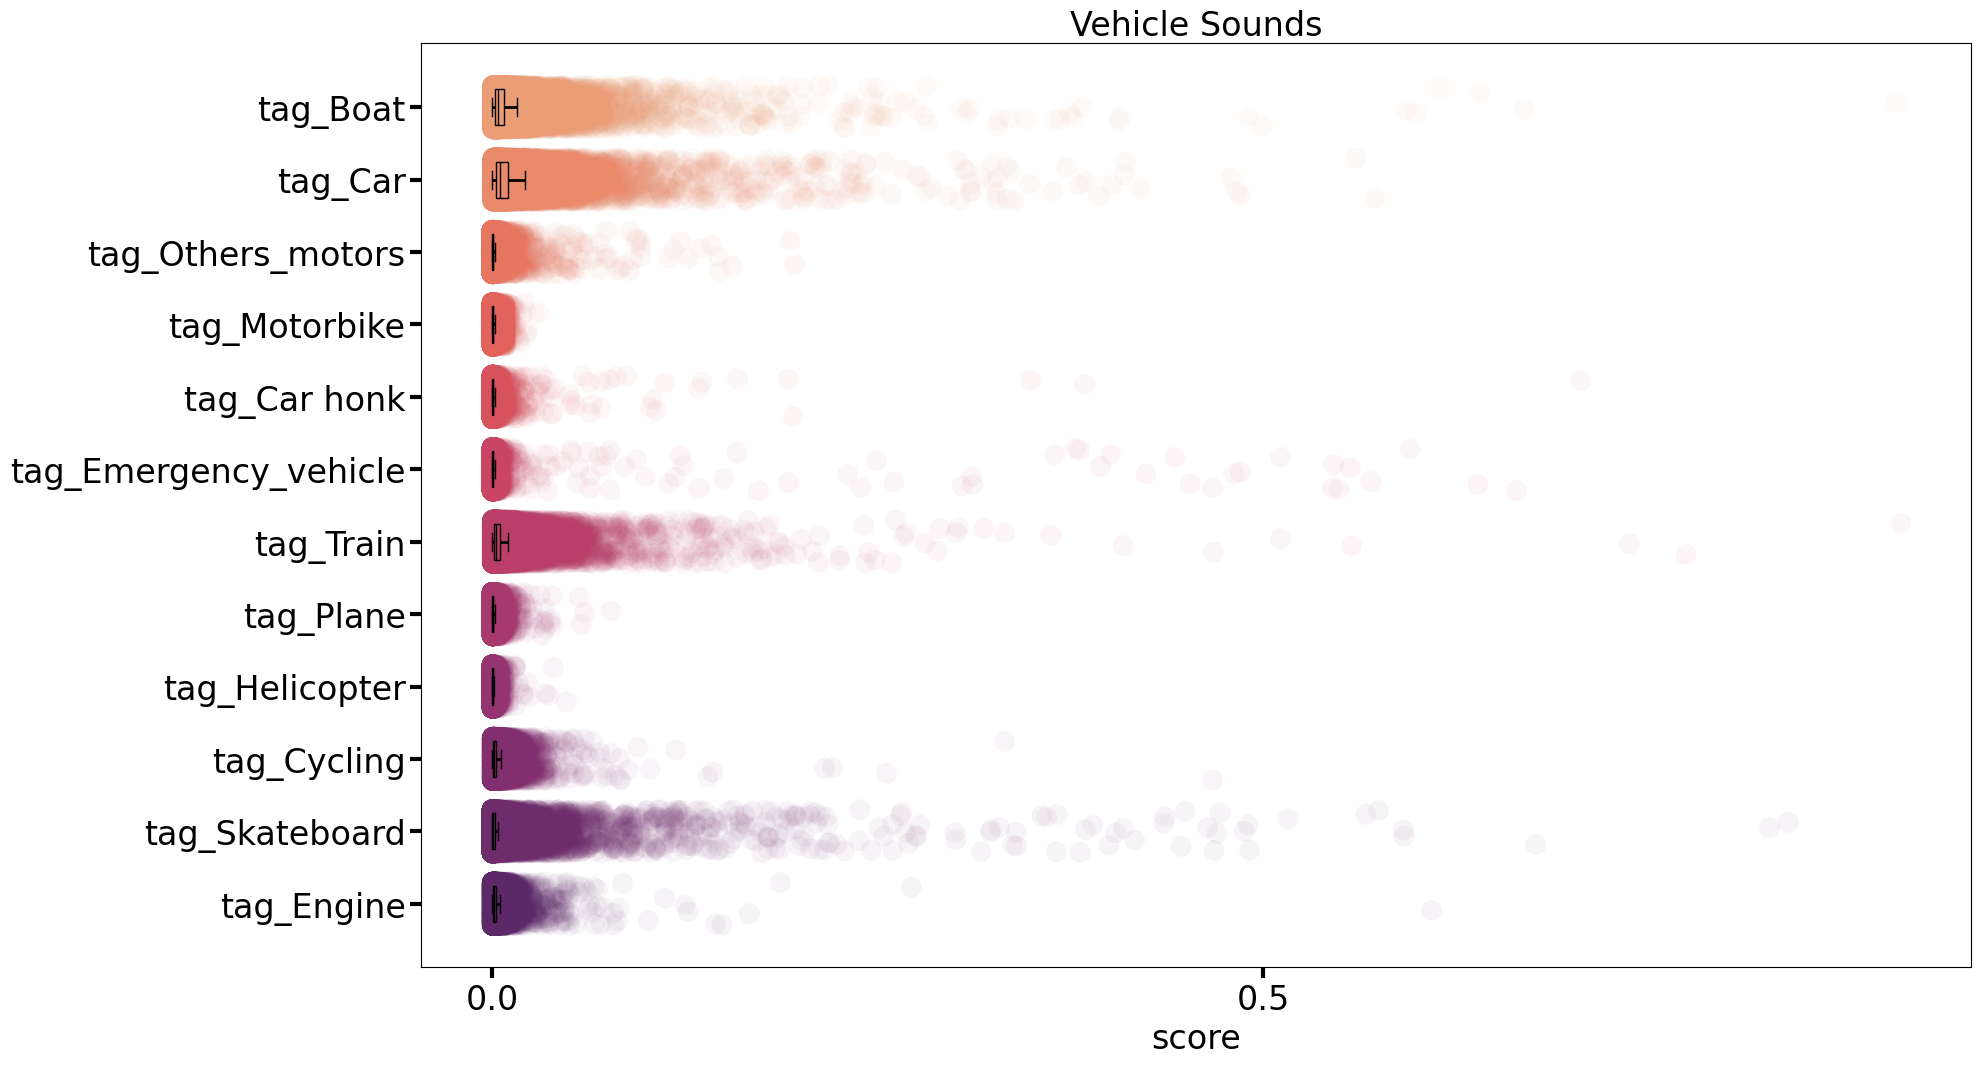

In [15]:
# Vehicle sounds

tags= [
 'tag_Boat',
 'tag_Car',
 'tag_Others_motors',
 'tag_Motorbike',
 'tag_Car honk',
 'tag_Emergency_vehicle',
 'tag_Train',
 'tag_Plane',
 'tag_Helicopter',
 'tag_Cycling',
 'tag_Skateboard',
 'tag_Engine',
]

df = pd.concat([
    make_df(tag_df, t) for t in tags
])

fig, ax = plt.subplots(figsize=(20, len(tags)))
dx='score'; dy='tag'; ort="h" 
#pal = sns.color_palette("rocket")
pal = sns.color_palette("flare", len(tags))

ax=sns.stripplot(x = dx, y = dy, data = df, palette = pal, hue = dy, edgecolor = "white",
                 size = 3, alpha=0.05, s=15, jitter = 0.3, zorder = 0, orient = ort)

ax=sns.boxplot(x = dx, y = dy, data = df, color = "black", width = .50, zorder = 10, 
               showcaps = True, boxprops = {'facecolor':'none', "zorder":10},
               showfliers=False, whiskerprops = {'linewidth':2, "zorder":10},
               saturation = 1, orient = ort)

ax.tick_params(width=3, size=8)

plt.xticks([0.0, 0.5, 1.0])
#plt.xlabel('')
plt.ylabel('')

plt.title("Vehicle Sounds")

if save_fig:
    #plt.savefig(f"{fig_save_path}/Environment_sounds.png", dpi=600, bbox_inches='tight')
    plt.savefig(f"{fig_save_path}/Vehicle_sounds.png", bbox_inches='tight')
    
plt.plot()


[]

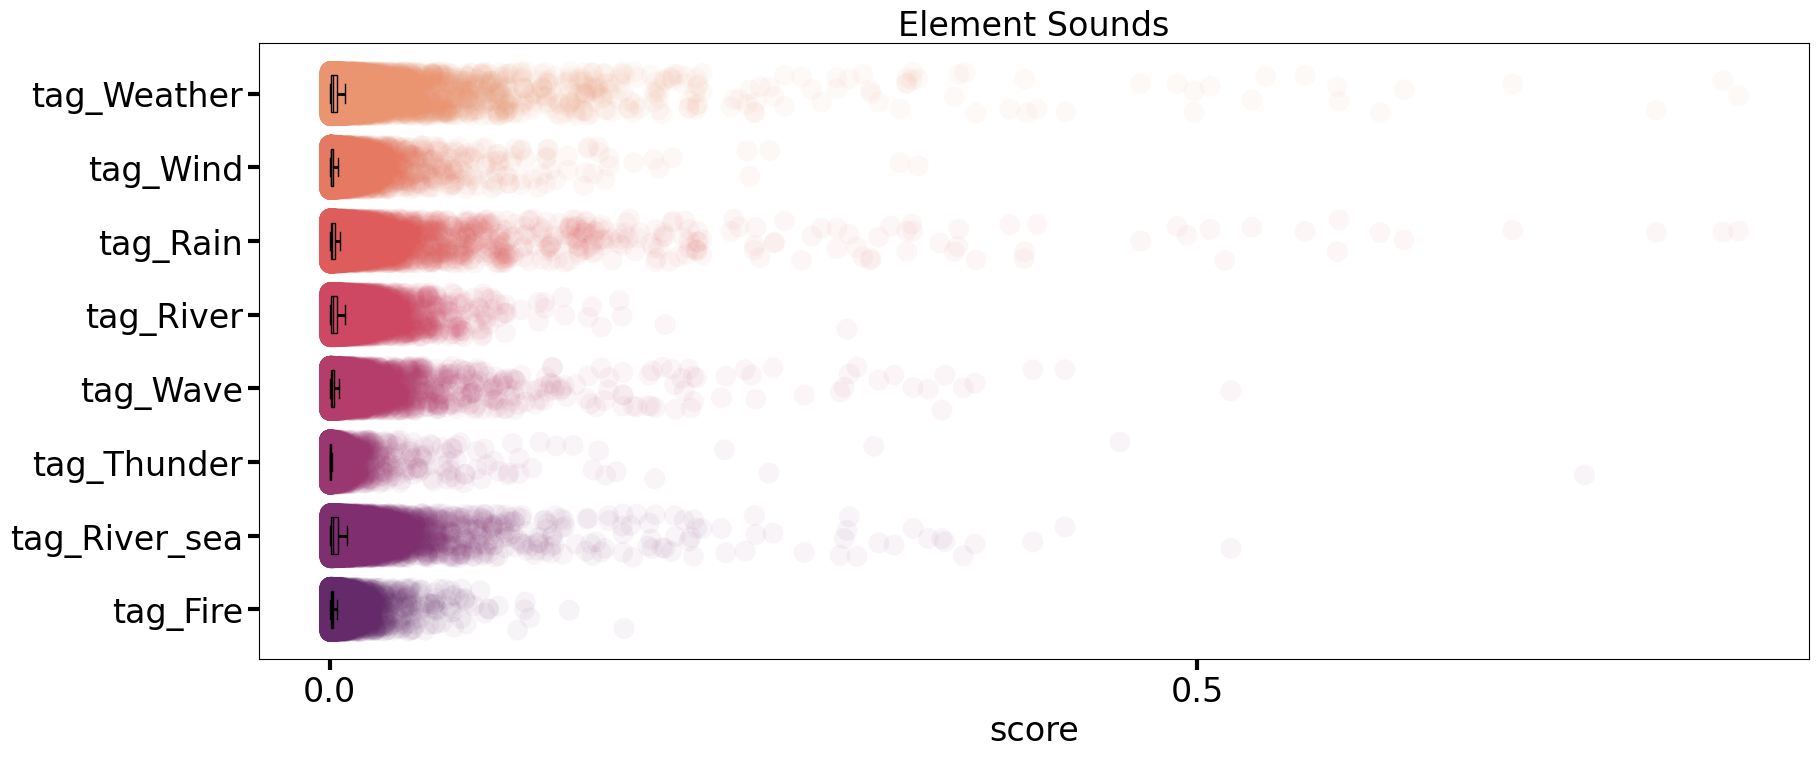

In [16]:


# Elements sounds

tags= [
 'tag_Weather',
 'tag_Wind',
 'tag_Rain',
 'tag_River',
 'tag_Wave',
 'tag_Thunder',
 'tag_River_sea',
 'tag_Fire',
]

df = pd.concat([
    make_df(tag_df, t) for t in tags
])

fig, ax = plt.subplots(figsize=(20, len(tags)))
dx='score'; dy='tag'; ort="h" 
#pal = sns.color_palette("rocket")
pal = sns.color_palette("flare", len(tags))

ax=sns.stripplot(x = dx, y = dy, data = df, palette = pal, hue = dy, edgecolor = "white",
                 size = 3, alpha=0.05, s=15, jitter = 0.3, zorder = 0, orient = ort)

ax=sns.boxplot(x = dx, y = dy, data = df, color = "black", width = .50, zorder = 10, 
               showcaps = True, boxprops = {'facecolor':'none', "zorder":10},
               showfliers=False, whiskerprops = {'linewidth':2, "zorder":10},
               saturation = 1, orient = ort)

ax.tick_params(width=3, size=8)

plt.xticks([0.0, 0.5, 1.0])
#plt.xlabel('')
plt.ylabel('')

plt.title("Element Sounds")
if save_fig:
    #plt.savefig(f"{fig_save_path}/Environment_sounds.png", dpi=600, bbox_inches='tight')
    plt.savefig(f"{fig_save_path}/Element_sounds.png", bbox_inches='tight')
    
plt.plot()




[]

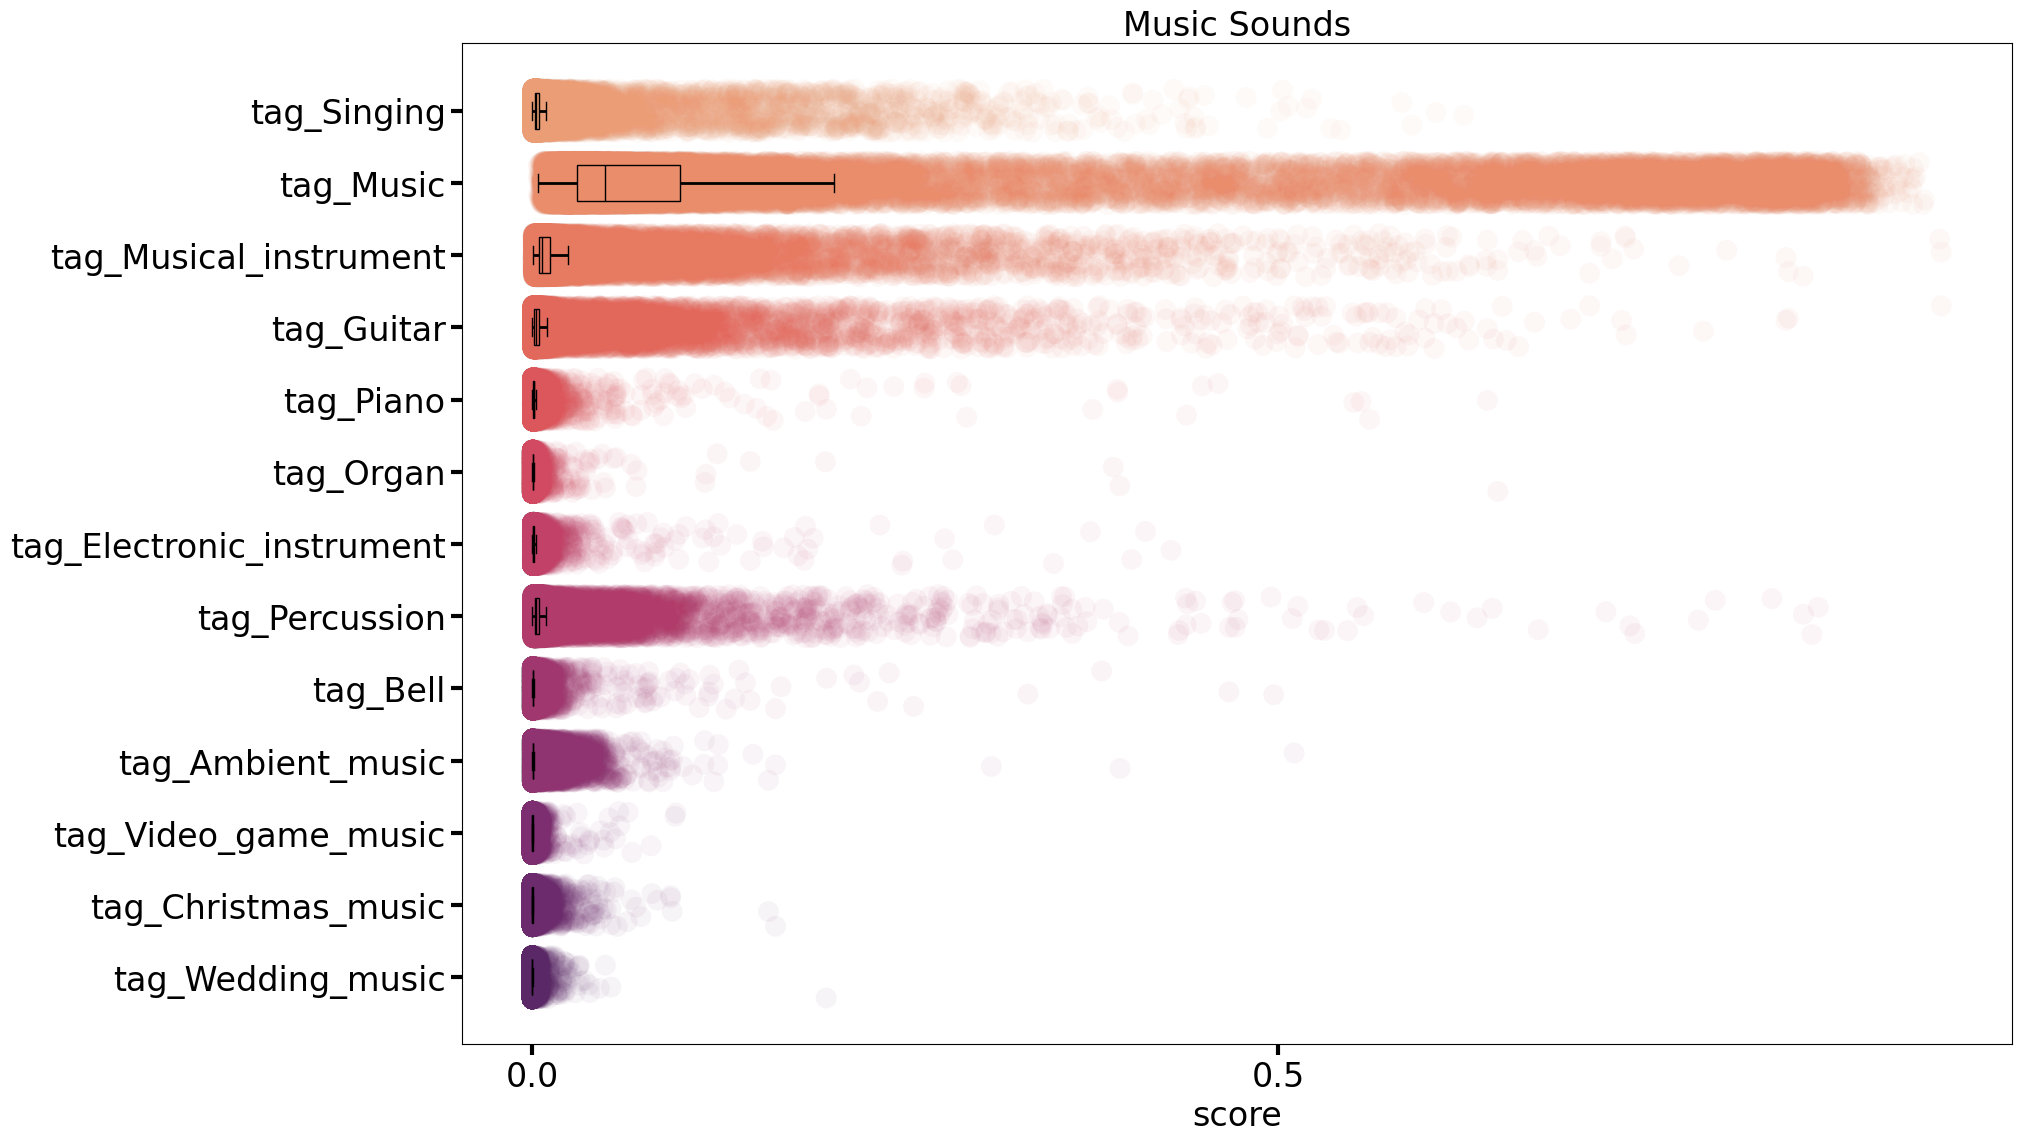

In [17]:
# Music sounds

tags= [
 'tag_Singing',
 'tag_Music',
 'tag_Musical_instrument',
 'tag_Guitar',
 'tag_Piano',
 'tag_Organ',
 'tag_Electronic_instrument',
 'tag_Percussion',
 'tag_Bell',
 'tag_Ambient_music',
 'tag_Video_game_music',
 'tag_Christmas_music',
 'tag_Wedding_music',
]


df = pd.concat([
    make_df(tag_df, t) for t in tags
])

fig, ax = plt.subplots(figsize=(20, len(tags)))
dx='score'; dy='tag'; ort="h" 
#pal = sns.color_palette("rocket")
pal = sns.color_palette("flare", len(tags))

ax=sns.stripplot(x = dx, y = dy, data = df, palette = pal, hue = dy, edgecolor = "white",
                 size = 3, alpha=0.05, s=15, jitter = 0.3, zorder = 0, orient = ort)

ax=sns.boxplot(x = dx, y = dy, data = df, color = "black", width = .50, zorder = 10, 
               showcaps = True, boxprops = {'facecolor':'none', "zorder":10},
               showfliers=False, whiskerprops = {'linewidth':2, "zorder":10},
               saturation = 1, orient = ort)

ax.tick_params(width=3, size=8)

plt.xticks([0.0, 0.5, 1.0])
#plt.xlabel('')
plt.ylabel('')

plt.title("Music Sounds")

if save_fig:
    #plt.savefig(f"{fig_save_path}/Environment_sounds.png", dpi=600, bbox_inches='tight')
    plt.savefig(f"{fig_save_path}/Music_sounds.png", bbox_inches='tight')
    
plt.plot()




[]

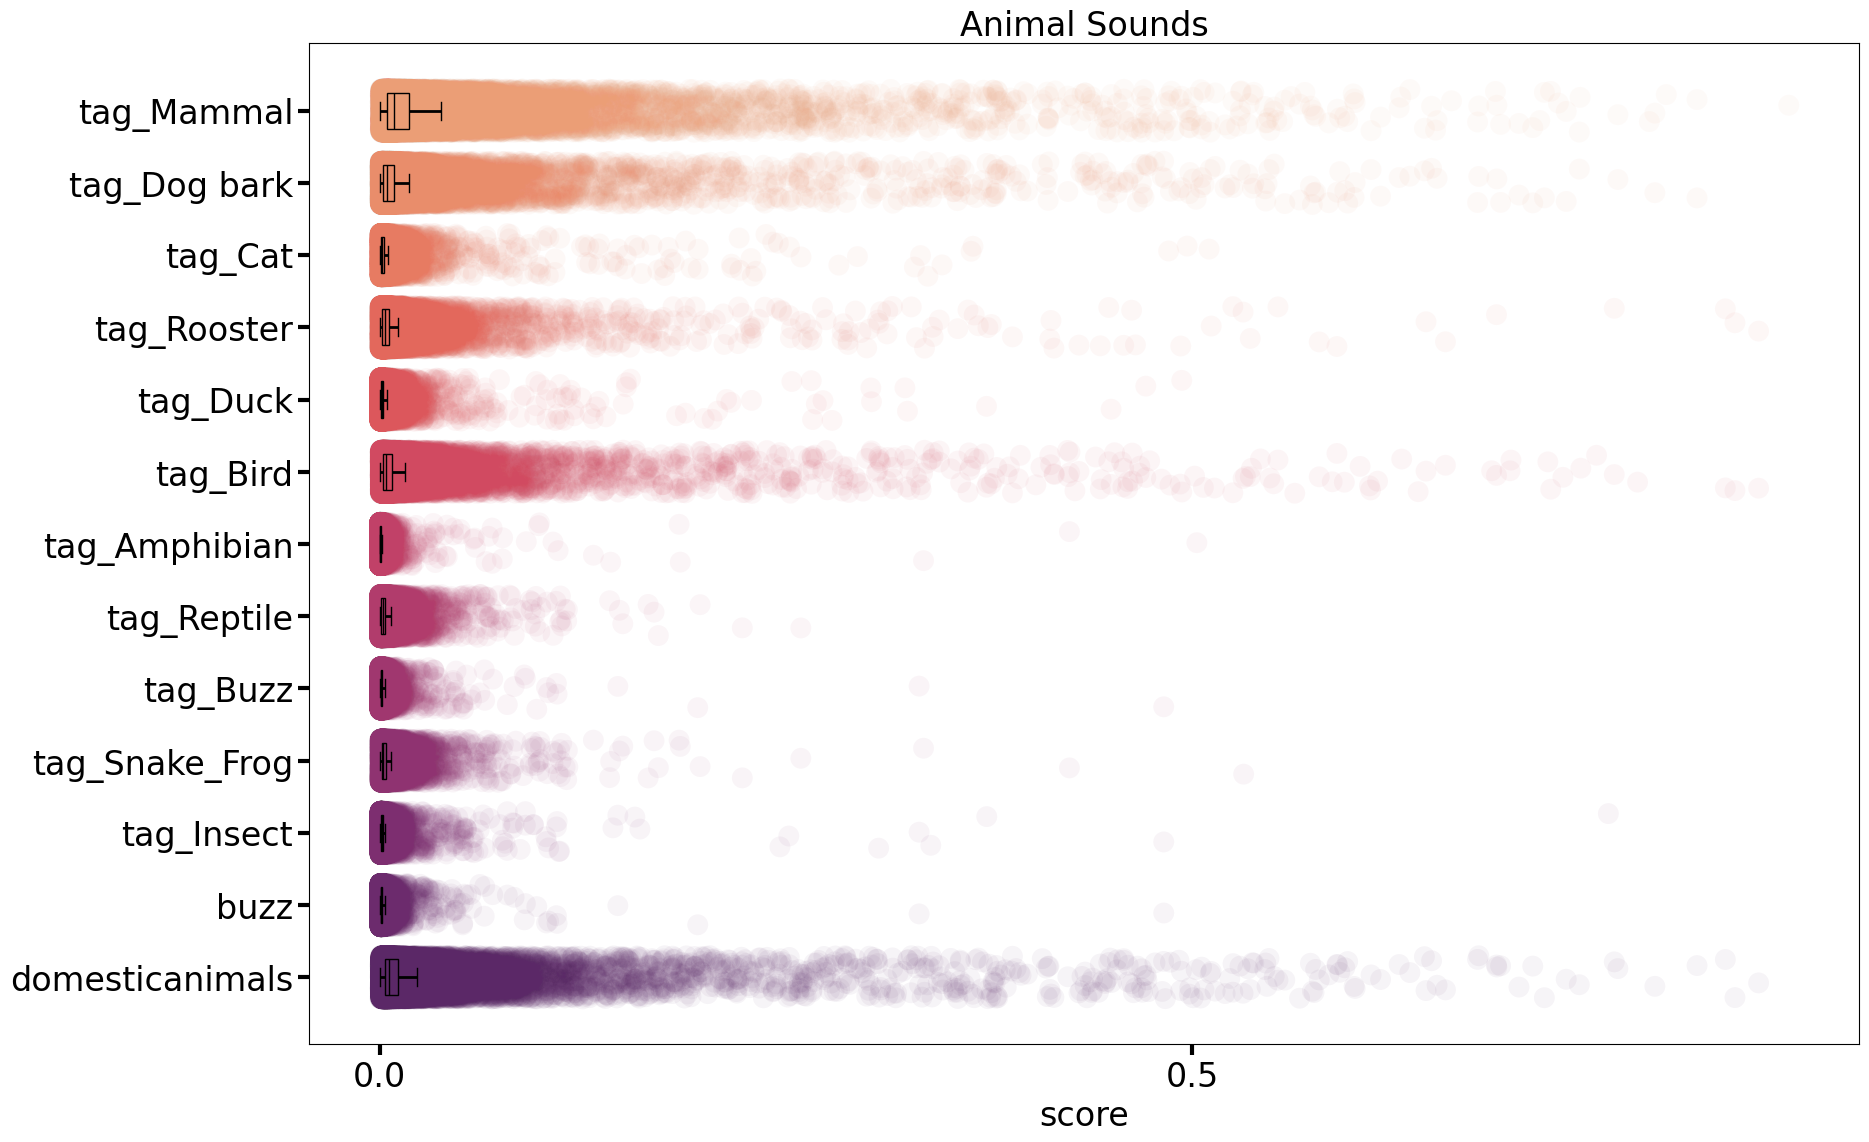

In [18]:
# Animal sounds

tags= [
 'tag_Mammal',
 'tag_Dog bark',
 'tag_Cat',
 'tag_Rooster',
 'tag_Duck',
 'tag_Bird',
 'tag_Amphibian',
 'tag_Reptile',
 'tag_Buzz',
 'tag_Snake_Frog',
 'tag_Insect', 
 'buzz',
 'domesticanimals',
]


df = pd.concat([
    make_df(tag_df, t) for t in tags
])

fig, ax = plt.subplots(figsize=(20, len(tags)))
dx='score'; dy='tag'; ort="h" 
#pal = sns.color_palette("rocket")
pal = sns.color_palette("flare", len(tags))

ax=sns.stripplot(x = dx, y = dy, data = df, palette = pal, hue = dy, edgecolor = "white",
                 size = 3, alpha=0.05, s=15, jitter = 0.3, zorder = 0, orient = ort)

ax=sns.boxplot(x = dx, y = dy, data = df, color = "black", width = .50, zorder = 10, 
               showcaps = True, boxprops = {'facecolor':'none', "zorder":10},
               showfliers=False, whiskerprops = {'linewidth':2, "zorder":10},
               saturation = 1, orient = ort)

ax.tick_params(width=3, size=8)

plt.xticks([0.0, 0.5, 1.0])
#plt.xlabel('')
plt.ylabel('')

plt.title("Animal Sounds")

if save_fig:
    #plt.savefig(f"{fig_save_path}/Environment_sounds.png", dpi=600, bbox_inches='tight')
    plt.savefig(f"{fig_save_path}/Animal_sounds.png", bbox_inches='tight')
    
plt.plot()



[]

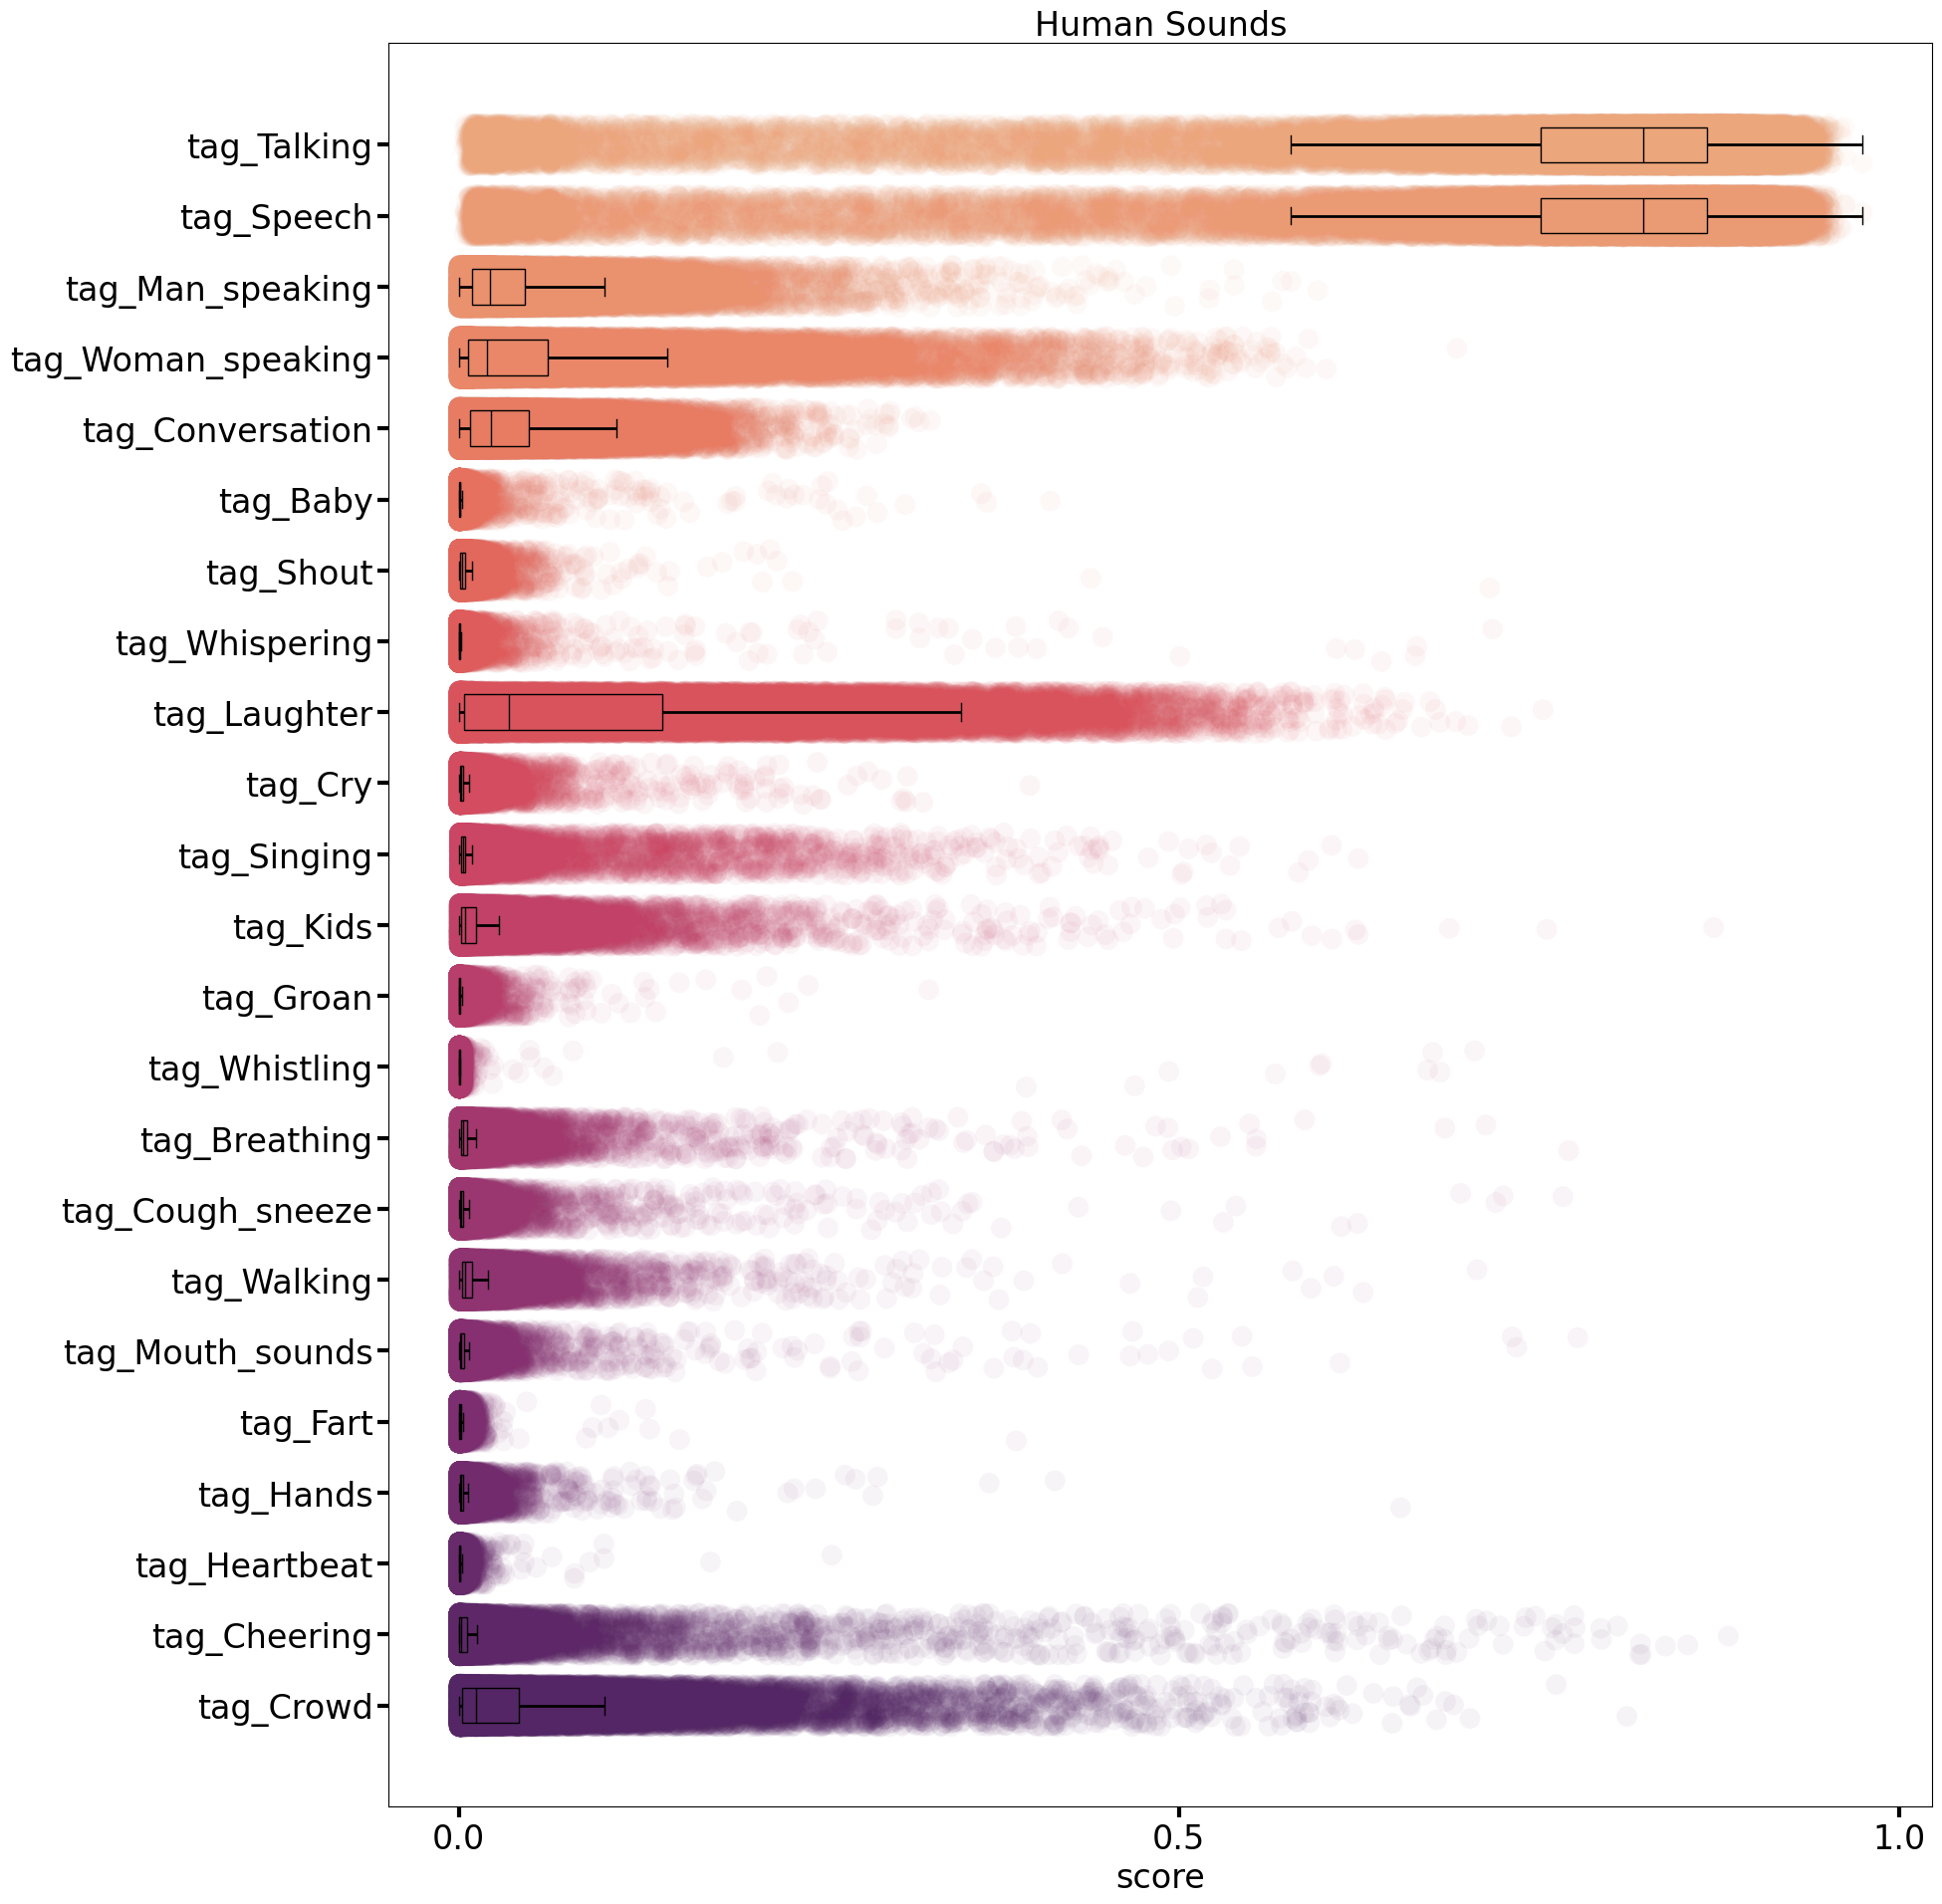

In [19]:
# Human sounds

tags= ['tag_Talking',
 'tag_Speech',
 'tag_Man_speaking',
 'tag_Woman_speaking',
 'tag_Conversation',
 'tag_Baby',
 'tag_Shout',
 'tag_Whispering',
 'tag_Laughter',
 'tag_Cry',
 'tag_Singing',
 'tag_Kids',
 'tag_Groan',
 'tag_Whistling',
 'tag_Breathing',
 'tag_Cough_sneeze',
 'tag_Walking',
 'tag_Mouth_sounds',
 'tag_Fart',
 'tag_Hands',
 'tag_Heartbeat',
 'tag_Cheering',
 'tag_Crowd',
]


df = pd.concat([
    make_df(tag_df, t) for t in tags
])

fig, ax = plt.subplots(figsize=(20, len(tags)))
dx='score'; dy='tag'; ort="h" 
#pal = sns.color_palette("rocket")
pal = sns.color_palette("flare", len(tags))

ax=sns.stripplot(x = dx, y = dy, data = df, palette = pal, hue = dy, edgecolor = "white",
                 size = 3, alpha=0.05, s=15, jitter = 0.3, zorder = 0, orient = ort)

ax=sns.boxplot(x = dx, y = dy, data = df, color = "black", width = .50, zorder = 10, 
               showcaps = True, boxprops = {'facecolor':'none', "zorder":10},
               showfliers=False, whiskerprops = {'linewidth':2, "zorder":10},
               saturation = 1, orient = ort)

ax.tick_params(width=3, size=8)

plt.xticks([0.0, 0.5, 1.0])
#plt.xlabel('')
plt.ylabel('')

plt.title("Human Sounds")

if save_fig:
    #plt.savefig(f"{fig_save_path}/Environment_sounds.png", dpi=600, bbox_inches='tight')
    plt.savefig(f"{fig_save_path}/Human_sounds.png", bbox_inches='tight')
    
plt.plot()


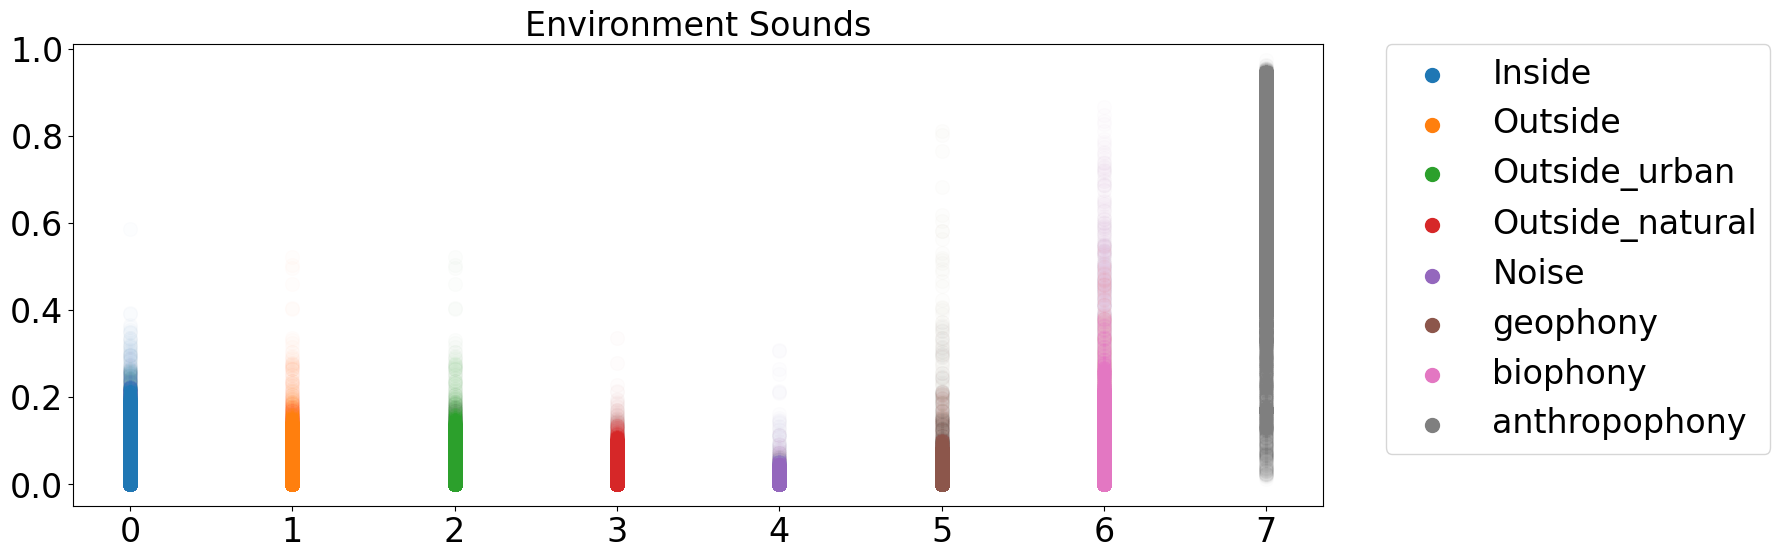

In [20]:
# Environment sounds

environ_tags= [
 'tag_Inside',
 'tag_Outside',
 'tag_Outside_urban',
 'tag_Outside_natural',
 'tag_Noise',
 'geophony',
 'biophony',
 'anthropophony',
]

fig, ax = plt.subplots(figsize=(20, 6))

for i, t in enumerate(environ_tags):
    ax.scatter(
        np.repeat(i, tag_df.shape[0]),
        tag_df[t],
        alpha=0.01,
        s=100,
        label=t.replace("tag_", ""),
    )

ax.set_ylim(-0.05, 1.01)

leg = plt.legend(
    loc='upper left',           # Anchor point for the legend box
    bbox_to_anchor=(1.05, 1),   # Position: 5% outside the right edge, at the top
    borderaxespad=0.,           # No padding between legend and axes boundary
)

for lh in leg.legend_handles:
    lh.set_alpha(1)

fig.subplots_adjust(right=0.75)

plt.title("Environment Sounds")
plt.show()

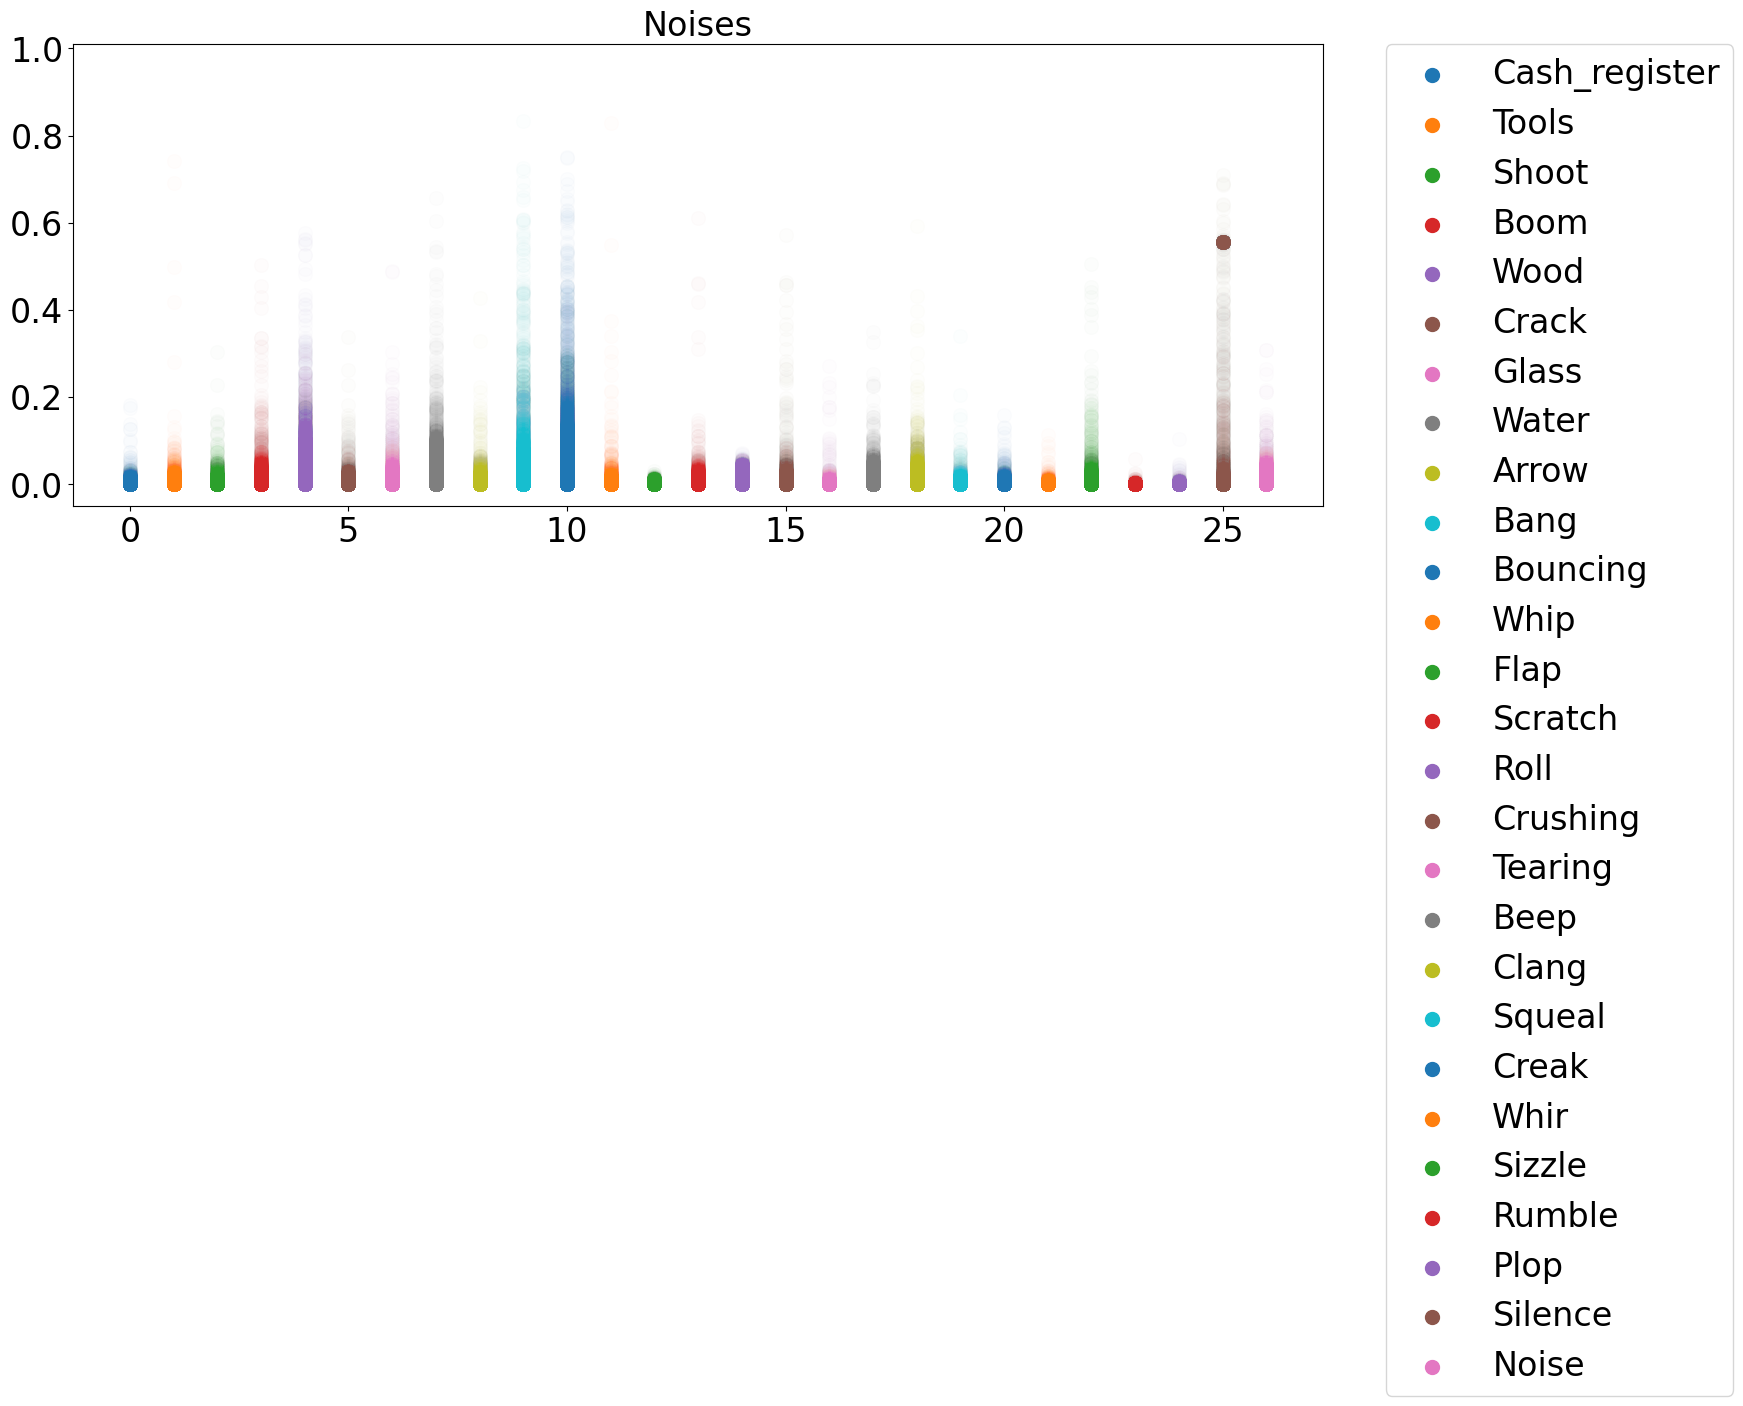

In [21]:
# Noise sounds

noises_tags= [
 'tag_Cash_register',
 'tag_Tools',
 'tag_Shoot',
 'tag_Boom',
 'tag_Wood',
 'tag_Crack',
 'tag_Glass',
 'tag_Water',
 'tag_Arrow',
 'tag_Bang',
 'tag_Bouncing',
 'tag_Whip',
 'tag_Flap',
 'tag_Scratch',
 'tag_Roll',
 'tag_Crushing',
 'tag_Tearing',
 'tag_Beep',
 'tag_Clang',
 'tag_Squeal',
 'tag_Creak',
 'tag_Whir',
 'tag_Sizzle',
 'tag_Rumble',
 'tag_Plop',
 'tag_Silence',
 'tag_Noise',    
]

fig, ax = plt.subplots(figsize=(20, 6))

for i, t in enumerate(noises_tags):
    ax.scatter(
        np.repeat(i, tag_df.shape[0]),
        tag_df[t],
        alpha=0.01,
        s=100,
        label=t.replace("tag_", ""),
    )

ax.set_ylim(-0.05, 1.01)

leg = plt.legend(
    loc='upper left',           # Anchor point for the legend box
    bbox_to_anchor=(1.05, 1),   # Position: 5% outside the right edge, at the top
    borderaxespad=0.,           # No padding between legend and axes boundary
)

for lh in leg.legend_handles:
    lh.set_alpha(1)

fig.subplots_adjust(right=0.75)

plt.title("Noises")
plt.show()

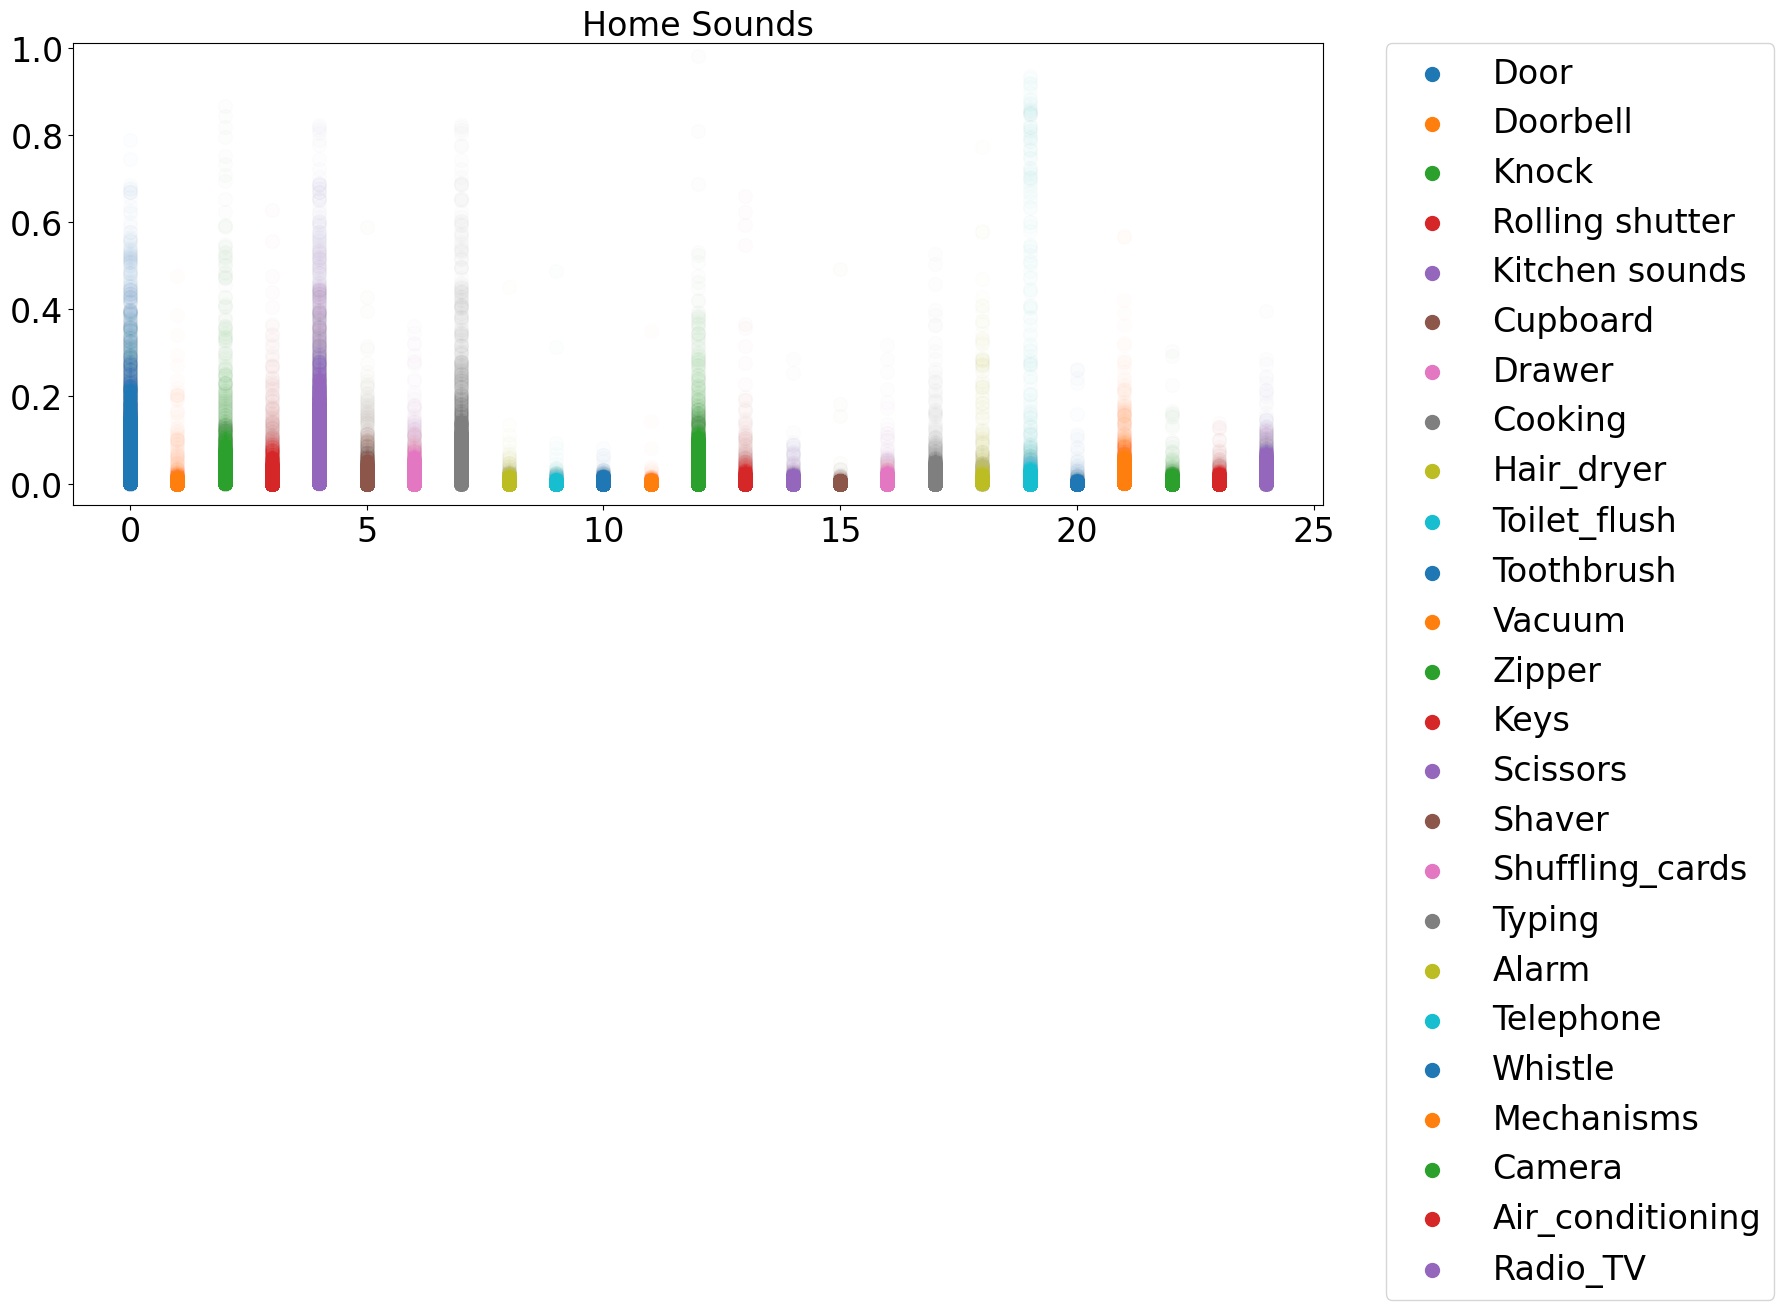

In [22]:
# Home sounds

home_tags= [
 'tag_Door',
 'tag_Doorbell',
 'tag_Knock',
 'tag_Rolling shutter',
 'tag_Kitchen sounds',
 'tag_Cupboard',
 'tag_Drawer',
 'tag_Cooking',
 'tag_Hair_dryer',
 'tag_Toilet_flush',
 'tag_Toothbrush',
 'tag_Vacuum',
 'tag_Zipper',
 'tag_Keys',
 'tag_Scissors',
 'tag_Shaver',
 'tag_Shuffling_cards',
 'tag_Typing',
 'tag_Alarm',
 'tag_Telephone',
 'tag_Whistle',
 'tag_Mechanisms',
 'tag_Camera',
 'tag_Air_conditioning',
 'tag_Radio_TV',    
]

fig, ax = plt.subplots(figsize=(20, 6))

for i, t in enumerate(home_tags):
    ax.scatter(
        np.repeat(i, tag_df.shape[0]),
        tag_df[t],
        alpha=0.01,
        s=100,
        label=t.replace("tag_", ""),
    )

ax.set_ylim(-0.05, 1.01)

leg = plt.legend(
    loc='upper left',           # Anchor point for the legend box
    bbox_to_anchor=(1.05, 1),   # Position: 5% outside the right edge, at the top
    borderaxespad=0.,           # No padding between legend and axes boundary
)

for lh in leg.legend_handles:
    lh.set_alpha(1)

fig.subplots_adjust(right=0.75)

plt.title("Home Sounds")
plt.show()


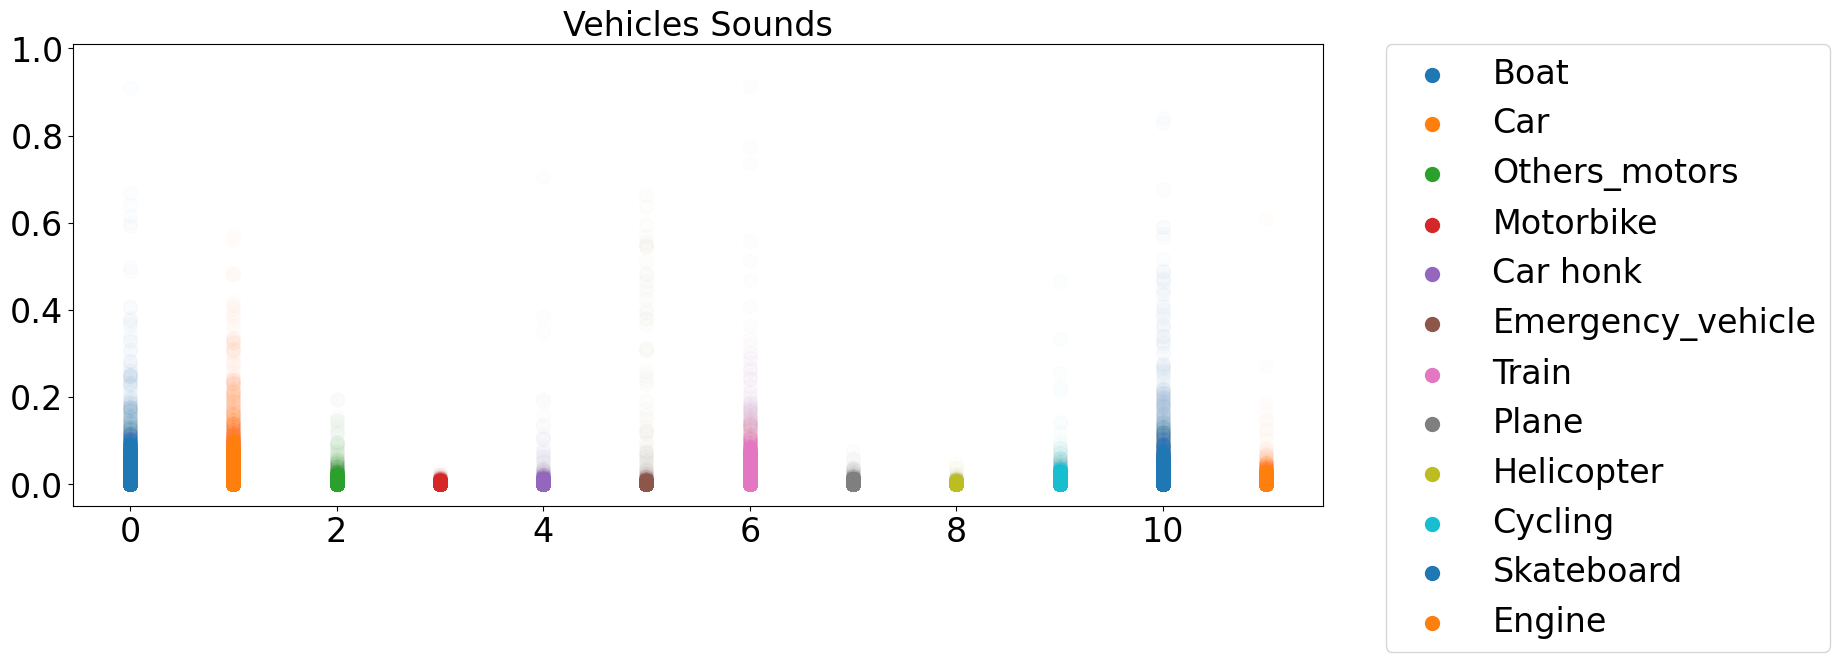

In [23]:
# Vehicle sounds

vehicles_tags= [
 'tag_Boat',
 'tag_Car',
 'tag_Others_motors',
 'tag_Motorbike',
 'tag_Car honk',
 'tag_Emergency_vehicle',
 'tag_Train',
 'tag_Plane',
 'tag_Helicopter',
 'tag_Cycling',
 'tag_Skateboard',
 'tag_Engine',
]

fig, ax = plt.subplots(figsize=(20, 6))

for i, t in enumerate(vehicles_tags):
    ax.scatter(
        np.repeat(i, tag_df.shape[0]),
        tag_df[t],
        alpha=0.01,
        s=100,
        label=t.replace("tag_", ""),
    )

ax.set_ylim(-0.05, 1.01)

leg = plt.legend(
    loc='upper left',           # Anchor point for the legend box
    bbox_to_anchor=(1.05, 1),   # Position: 5% outside the right edge, at the top
    borderaxespad=0.,           # No padding between legend and axes boundary
)

for lh in leg.legend_handles:
    lh.set_alpha(1)

fig.subplots_adjust(right=0.75)

plt.title("Vehicles Sounds")
plt.show()


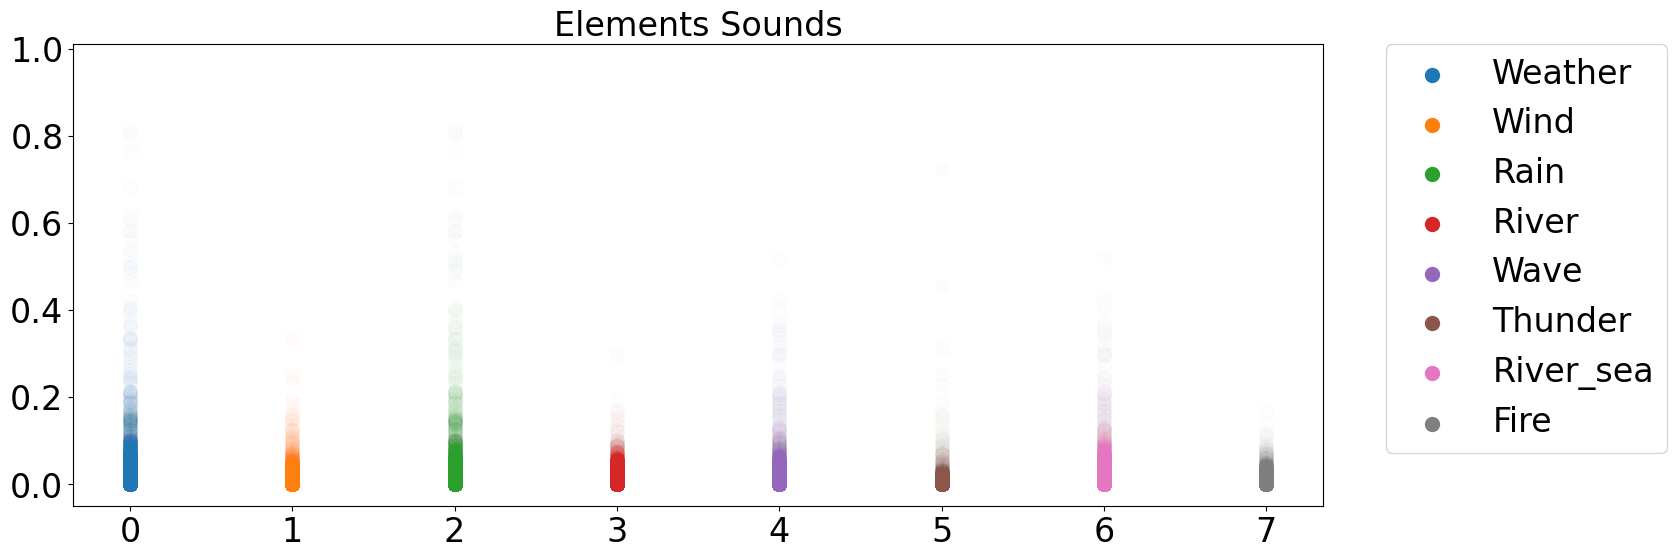

In [24]:
# Elements sounds

elements_tags= [
 'tag_Weather',
 'tag_Wind',
 'tag_Rain',
 'tag_River',
 'tag_Wave',
 'tag_Thunder',
 'tag_River_sea',
 'tag_Fire',
]

fig, ax = plt.subplots(figsize=(20, 6))

for i, t in enumerate(elements_tags):
    ax.scatter(
        np.repeat(i, tag_df.shape[0]),
        tag_df[t],
        alpha=0.01,
        s=100,
        label=t.replace("tag_", ""),
    )

ax.set_ylim(-0.05, 1.01)

leg = plt.legend(
    loc='upper left',           # Anchor point for the legend box
    bbox_to_anchor=(1.05, 1),   # Position: 5% outside the right edge, at the top
    borderaxespad=0.,           # No padding between legend and axes boundary
)

for lh in leg.legend_handles:
    lh.set_alpha(1)

fig.subplots_adjust(right=0.75)

plt.title("Elements Sounds")
plt.show()


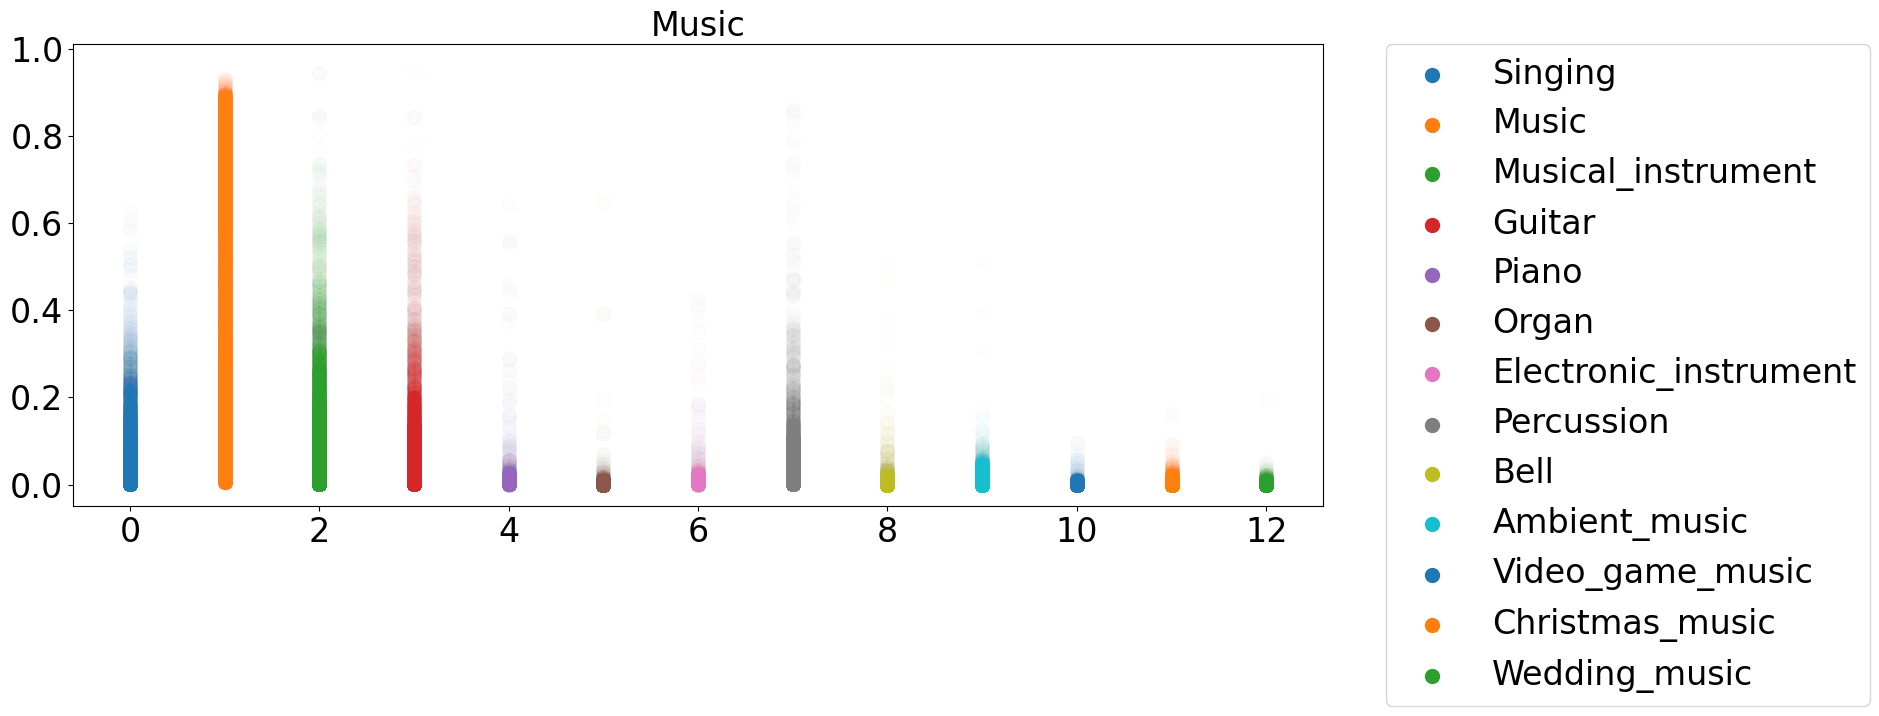

In [25]:
# Music sounds

music_tags= [
 'tag_Singing',
 'tag_Music',
 'tag_Musical_instrument',
 'tag_Guitar',
 'tag_Piano',
 'tag_Organ',
 'tag_Electronic_instrument',
 'tag_Percussion',
 'tag_Bell',
 'tag_Ambient_music',
 'tag_Video_game_music',
 'tag_Christmas_music',
 'tag_Wedding_music',
]

fig, ax = plt.subplots(figsize=(20, 6))

for i, t in enumerate(music_tags):
    ax.scatter(
        np.repeat(i, tag_df.shape[0]),
        tag_df[t],
        alpha=0.01,
        s=100,
        label=t.replace("tag_", ""),
    )

ax.set_ylim(-0.05, 1.01)

leg = plt.legend(
    loc='upper left',           # Anchor point for the legend box
    bbox_to_anchor=(1.05, 1),   # Position: 5% outside the right edge, at the top
    borderaxespad=0.,           # No padding between legend and axes boundary
)

for lh in leg.legend_handles:
    lh.set_alpha(1)

fig.subplots_adjust(right=0.75)

plt.title("Music")
plt.show()


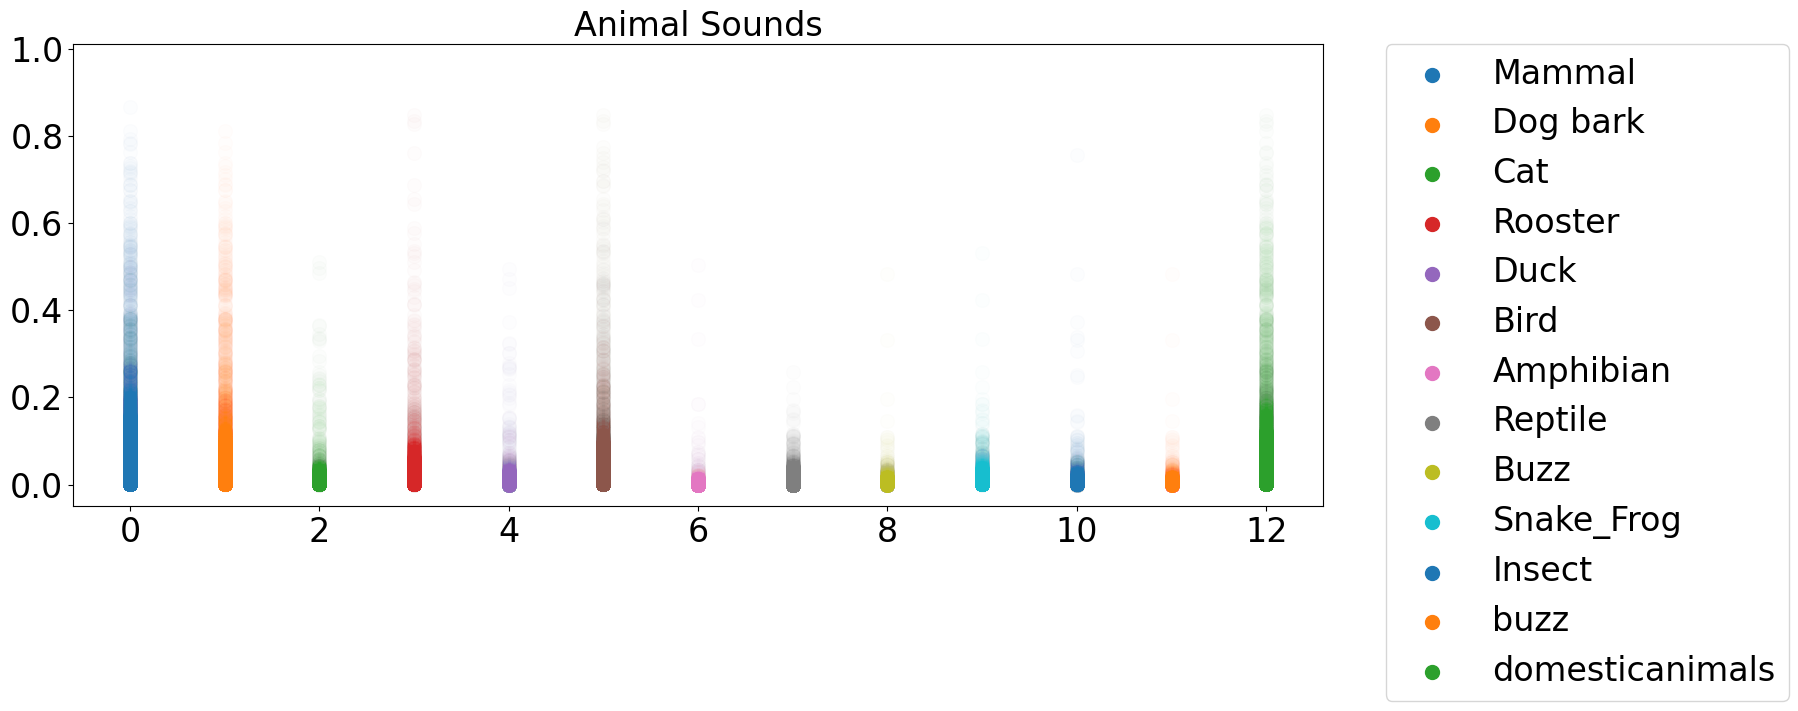

In [26]:
# Animal sounds

animal_tags= [
 'tag_Mammal',
 'tag_Dog bark',
 'tag_Cat',
 'tag_Rooster',
 'tag_Duck',
 'tag_Bird',
 'tag_Amphibian',
 'tag_Reptile',
 'tag_Buzz',
 'tag_Snake_Frog',
 'tag_Insect', 
 'buzz',
 'domesticanimals',
]

fig, ax = plt.subplots(figsize=(20, 6))

for i, t in enumerate(animal_tags):
    ax.scatter(
        np.repeat(i, tag_df.shape[0]),
        tag_df[t],
        alpha=0.01,
        s=100,
        label=t.replace("tag_", ""),
    )

ax.set_ylim(-0.05, 1.01)

leg = plt.legend(
    loc='upper left',           # Anchor point for the legend box
    bbox_to_anchor=(1.05, 1),   # Position: 5% outside the right edge, at the top
    borderaxespad=0.,           # No padding between legend and axes boundary
)

for lh in leg.legend_handles:
    lh.set_alpha(1)

fig.subplots_adjust(right=0.75)

plt.title("Animal Sounds")
plt.show()


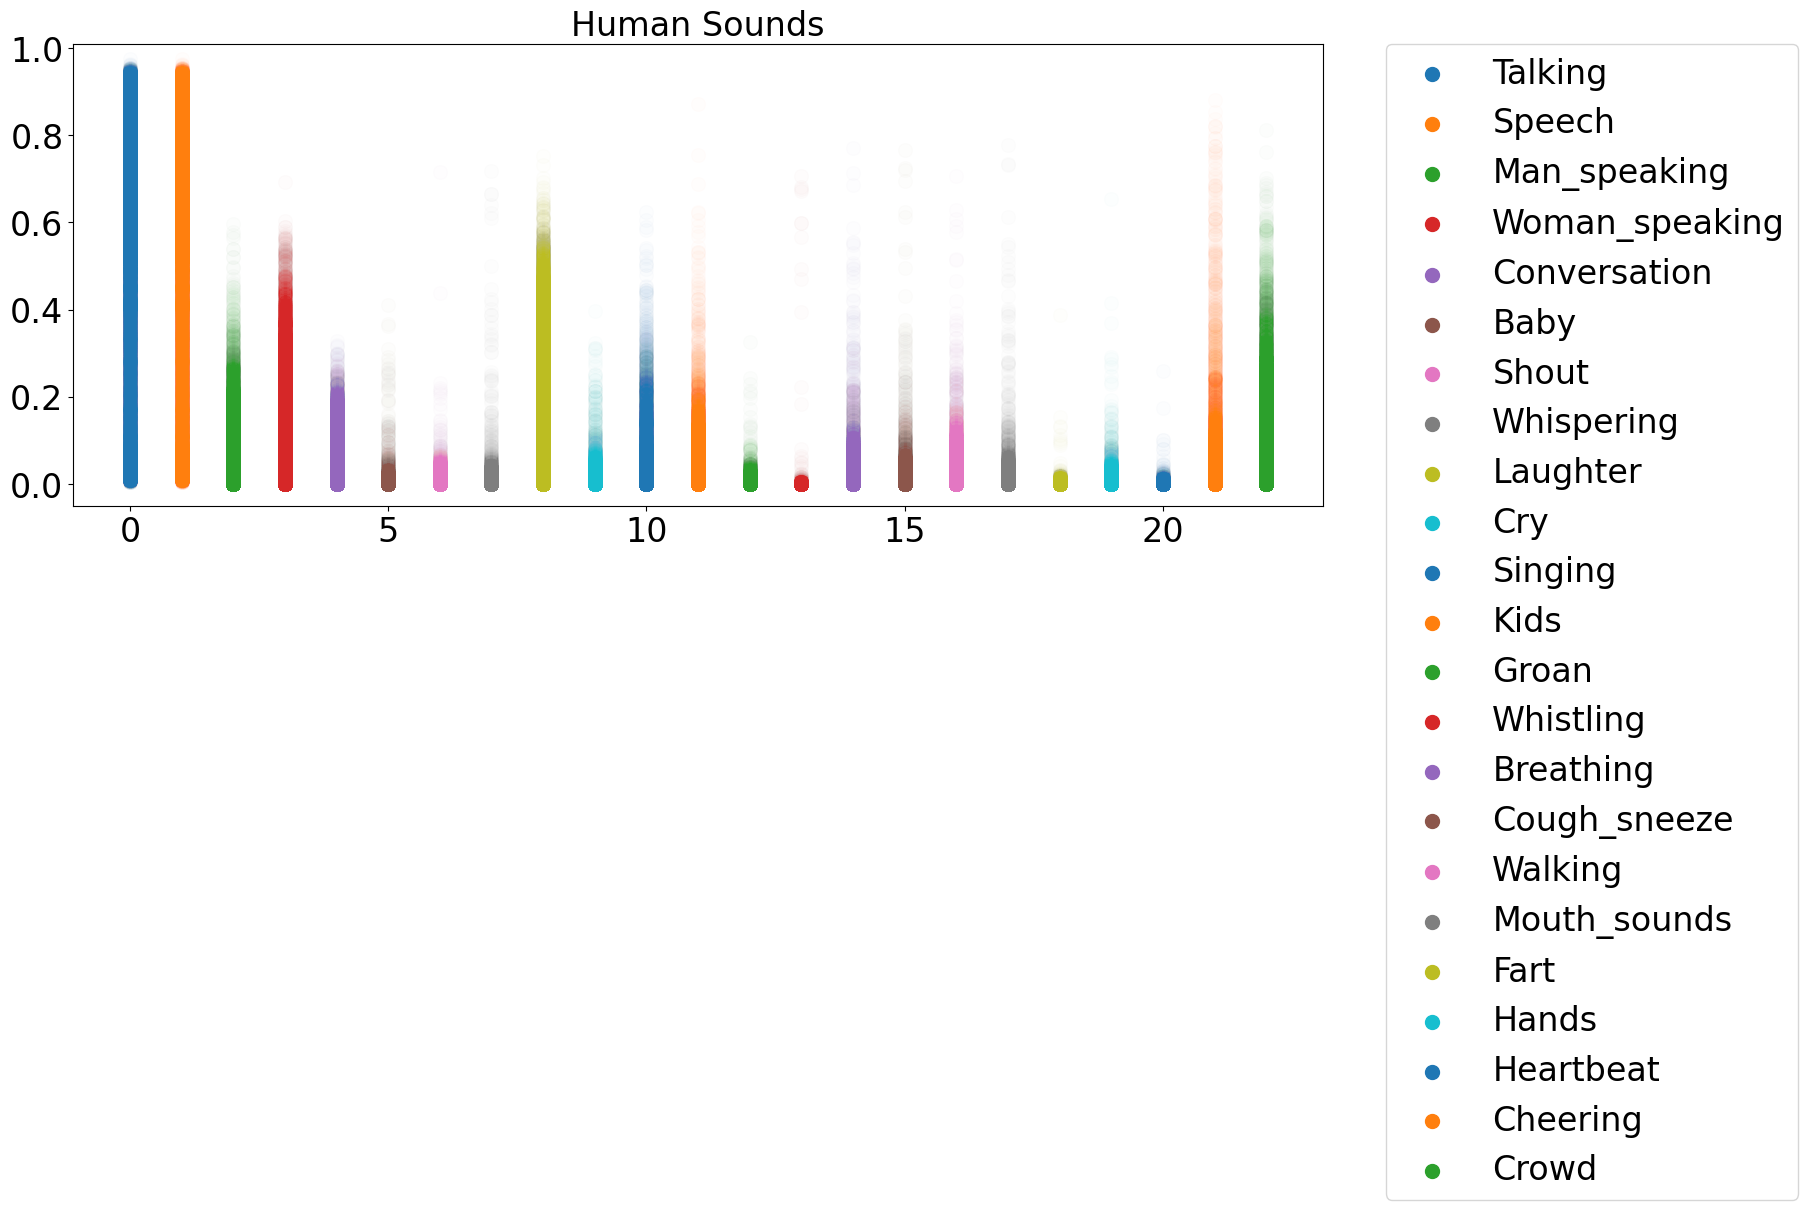

In [27]:
# Human sounds

human_tags= ['tag_Talking',
 'tag_Speech',
 'tag_Man_speaking',
 'tag_Woman_speaking',
 'tag_Conversation',
 'tag_Baby',
 'tag_Shout',
 'tag_Whispering',
 'tag_Laughter',
 'tag_Cry',
 'tag_Singing',
 'tag_Kids',
 'tag_Groan',
 'tag_Whistling',
 'tag_Breathing',
 'tag_Cough_sneeze',
 'tag_Walking',
 'tag_Mouth_sounds',
 'tag_Fart',
 'tag_Hands',
 'tag_Heartbeat',
 'tag_Cheering',
 'tag_Crowd',
]

fig, ax = plt.subplots(figsize=(20, 6))

for i, t in enumerate(human_tags):
    ax.scatter(
        np.repeat(i, tag_df.shape[0]),
        tag_df[t],
        alpha=0.01,
        s=100,
        label=t.replace("tag_", ""),
    )

ax.set_ylim(-0.05, 1.01)

leg = plt.legend(
    loc='upper left',           # Anchor point for the legend box
    bbox_to_anchor=(1.05, 1),   # Position: 5% outside the right edge, at the top
    borderaxespad=0.,           # No padding between legend and axes boundary
)

for lh in leg.legend_handles:
    lh.set_alpha(1)

fig.subplots_adjust(right=0.75)

plt.title("Human Sounds")
plt.show()

